# PopOut Game: MCTS vs Decision Trees

This notebook implements and compares two AI algorithms for playing the PopOut game:
- **Monte Carlo Tree Search (MCTS) with UCT**: A probabilistic search algorithm
- **Decision Trees**: A supervised learning approach

We'll analyze their performance, efficiency, and strategy differences.

## 1. Import Required Libraries

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec
import seaborn as sns
from collections import Counter, defaultdict
import random
import time
from copy import deepcopy
from typing import List, Tuple, Dict, Optional
import warnings
from scipy.stats import binomtest
warnings.filterwarnings('ignore')

# Import from project files
import sys
sys.path.append('.')
from logic import PopOutGame, MAX_ROLLOUT_MOVES
from interface import HumanPlayer, AIPlayer

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)

## 2. Implement PopOut Game Environment

The PopOut game is a combinatorial game where players take turns removing items from rows/columns until all items are removed.

In [3]:
    # PopOut Game is now imported from logic.py
# The game uses the Connect 4 variant with pop mechanics

print("=== PopOut Game Information ===\n")
print("PopOutGame (imported from logic.py):")
print("- Board size: 6 rows x 7 columns")
print("- Players: Player 1 (X) and Player 2 (O)")
print("- Win condition: Connect 4 discs horizontally, vertically, or diagonally")
print("\nAvailable moves:")
print("  1. DROP: Add your disc to the top of any non-full column")
print("  2. POP: Remove one of your discs from the bottom (others fall down)")
print("\nSpecial rules:")
print("  - Simultaneous four-in-rows after a pop: popper wins")
print("  - Full board: player to move can declare a draw")
print("  - Repetition: 3x same position allows draw declaration")

# Create a sample game
sample_game = PopOutGame(rows=6, cols=7)
print("\n=== Sample Board State ===")
print(sample_game)
print()

# Show legal moves
print("Legal moves for Player 1:")
moves = sample_game.get_legal_moves()
drops = [m[1] + 1 for m in moves if m[0] == 'drop']
pops = [m[1] + 1 for m in moves if m[0] == 'pop']
print(f"  DROP columns: {drops}")
print(f"  POP columns: {pops}")

=== PopOut Game Information ===

PopOutGame (imported from logic.py):
- Board size: 6 rows x 7 columns
- Players: Player 1 (X) and Player 2 (O)
- Win condition: Connect 4 discs horizontally, vertically, or diagonally

Available moves:
  1. DROP: Add your disc to the top of any non-full column
  2. POP: Remove one of your discs from the bottom (others fall down)

Special rules:
  - Simultaneous four-in-rows after a pop: popper wins
  - Full board: player to move can declare a draw
  - Repetition: 3x same position allows draw declaration

=== Sample Board State ===
  1 2 3 4 5 6 7
  -------------
6 . . . . . . .
5 . . . . . . .
4 . . . . . . .
3 . . . . . . .
2 . . . . . . .
1 . . . . . . .
  -------------
Player 1's turn

Legal moves for Player 1:
  DROP columns: [1, 2, 3, 4, 5, 6, 7]
  POP columns: []


## 3. Monte Carlo Tree Search (MCTS) Implementation

MCTS is an adversarial search algorithm that explores the game tree using UCT (Upper Confidence Bound for Trees) as the evaluation function. We'll implement different strategies and compare their performance.

#### 3.1 Standard MCTS (Pure UCT)
Exploration via Upper Bound Confidence fórmula, random rollout  

In [4]:
Move = Tuple[str, int]


class MCTSNode:
    """
    A node in the MCTS search tree.

    wins are accumulated from the perspective of the player who just moved
    into the node.
    """

    __slots__ = (
        "state",
        "move",
        "parent",
        "children",
        "visits",
        "wins",
        "untried",
        "player",
        "rave_visits",
        "rave_wins",
        "prior_wins",
    )

    def __init__(
        self,
        state,
        move: Optional[Move] = None,
        parent: Optional["MCTSNode"] = None,
    ):
        self.state = state
        self.move = move
        self.parent = parent
        self.children: List["MCTSNode"] = []
        self.visits = 0
        self.wins = 0.0
        self.player = 3 - state.current_player
        self.untried: List[Move] = state.get_legal_moves()
        random.shuffle(self.untried)

        self.rave_visits: Dict[Move, int] = defaultdict(int)
        self.rave_wins: Dict[Move, float] = defaultdict(float)
        self.prior_wins = 0.0

    def uct_score(self, c: float = math.sqrt(2)) -> float:
        if self.visits == 0:
            return float("inf")

        parent_visits = self.parent.visits if self.parent else self.visits
        parent_visits = max(parent_visits, 1)
        exploitation = (self.wins + self.prior_wins) / self.visits
        exploration = c * math.sqrt(math.log(parent_visits) / self.visits)
        return exploitation + exploration

    def is_fully_expanded(self) -> bool:
        return len(self.untried) == 0

    def is_terminal(self) -> bool:
        return self.state.game_over

    def best_child(self, c: float = math.sqrt(2)) -> "MCTSNode":
        return max(self.children, key=lambda child: child.uct_score(c))

    def most_visited_child(self) -> "MCTSNode":
        return max(self.children, key=lambda child: child.visits)

    def expand(self) -> "MCTSNode":
        move = self.untried.pop()
        new_state = self.state.copy()
        new_state.make_move(move[0], move[1])
        child = MCTSNode(new_state, move=move, parent=self)
        self.children.append(child)
        return child

    def __repr__(self) -> str:
        return (
            f"MCTSNode(move={self.move}, visits={self.visits}, "
            f"wins={self.wins:.1f}, children={len(self.children)})"
        )


class MCTS:
    """Standard Monte Carlo Tree Search with UCT selection."""

    reason = "MCTS"

    def __init__(
        self,
        time_limit: float = 1.0,
        iterations: Optional[int] = None,
        c: float = math.sqrt(2),
    ):
        self.time_limit = time_limit
        self.iterations = iterations
        self.c = c
        self.root: Optional[MCTSNode] = None
        self.last_search_stats: Dict[str, object] = {}

    def choose_move(self, game) -> Optional[Move]:
        result = self.search(game, return_stats=False)
        return result

    def search(self, game, return_stats: bool = False):
        legal = game.get_legal_moves()
        if not legal:
            stats = self._empty_stats(None, 0.0)
            return (None, stats) if return_stats else None
        if len(legal) == 1:
            stats = self._empty_stats(legal[0], 0.0)
            return (legal[0], stats) if return_stats else legal[0]

        self.root = MCTSNode(game.copy())
        elapsed = self._run_search()
        best = self.root.most_visited_child() if self.root.children else None
        move = best.move if best else random.choice(legal)
        stats = self._build_stats(move, elapsed)
        self.last_search_stats = stats
        return (move, stats) if return_stats else move

    def _run_search(self) -> float:
        start = time.time()
        n = 0
        while True:
            if self.iterations is not None and n >= self.iterations:
                break
            if time.time() - start > self.time_limit:  # hard cap por jogada
                break

            node = self._select(self.root)
            if not node.is_terminal():
                node = self._expand(node)
            reward = self._simulate(node)
            self._backpropagate(node, reward)
            n += 1
        return time.time() - start

    def _select(self, node: MCTSNode) -> MCTSNode:
        while node.is_fully_expanded() and not node.is_terminal():
            if not node.children:
                break
            node = node.best_child(self.c)
        return node

    def _expand(self, node: MCTSNode) -> MCTSNode:
        if node.untried:
            return node.expand()
        return node

    def _simulate(self, node: MCTSNode) -> float:
        state = node.state.copy()
        mover = node.player
        moves_played = 0

        while not state.game_over:
            if moves_played >= MAX_ROLLOUT_MOVES:
                return 0.5
            moves = state.get_legal_moves()
            if not moves:
                break
            move = random.choice(moves)
            state.make_move(move[0], move[1])
            moves_played += 1

        return self._outcome(state, mover)

    def _backpropagate(self, node: MCTSNode, reward: float) -> None:
        root_player = self.root.state.current_player
        while node is not None:
            node.visits += 1
            if node.player == root_player:
                node.wins += reward
            else:
                node.wins += 1 - reward
            node = node.parent

    @staticmethod
    def _outcome(state, player: int) -> float:
        if state.winner == player:
            return 1.0
        if state.is_draw or state.winner is None:
            return 0.5
        return 0.0

    def get_move_statistics(self) -> List[Dict[str, object]]:
        if self.root is None:
            return []
        stats = []
        for child in self.root.children:
            stats.append(
                {
                    "move": child.move,
                    "visits": child.visits,
                    "win_rate": child.wins / child.visits if child.visits else 0.0,
                    "uct": child.uct_score(self.c),
                }
            )
        return sorted(stats, key=lambda item: item["visits"], reverse=True)

    def _build_stats(self, move: Optional[Move], elapsed: float) -> Dict[str, object]:
        move_stats = self.get_move_statistics()
        chosen = next((item for item in move_stats if item["move"] == move), None)
        return {
            "reason": self.reason,
            "elapsed_s": elapsed,
            "root_sims": self.root.visits if self.root else 0,
            "n_children": len(self.root.children) if self.root else 0,
            "chosen_visits": chosen["visits"] if chosen else 0,
            "chosen_wr": chosen["win_rate"] if chosen else 0.0,
            "move_stats": move_stats,
        }

    def _empty_stats(self, move: Optional[Move], elapsed: float) -> Dict[str, object]:
        return {
            "reason": self.reason,
            "elapsed_s": elapsed,
            "root_sims": 0,
            "n_children": 0,
            "chosen_visits": 0,
            "chosen_wr": 0.0,
            "move_stats": [],
            "move": move,
        }


#### 3.2 MCTS with RAPID ACTION VALUE ESTIMATION
Every move seen during a rollout is credited as if it had been played
first — the AMAF assumption.  The RAVE bias decays as node visits grow
(parameter k controls the decay rate).

In [5]:
class MCTS_RAVE(MCTS):
    """MCTS with RAVE / AMAF statistics."""

    reason = "MCTS RAVE"

    def __init__(
        self,
        time_limit: float = 1.0,
        iterations: Optional[int] = None,
        c: float = math.sqrt(2),
        k: float = 1000,
    ):
        super().__init__(time_limit=time_limit, iterations=iterations, c=c)
        self.k = k

    def _select(self, node: MCTSNode) -> MCTSNode:
        while node.is_fully_expanded() and not node.is_terminal():
            if not node.children:
                break
            node = self._best_rave_child(node)
        return node

    def _best_rave_child(self, node: MCTSNode) -> MCTSNode:
        def rave_value(child: MCTSNode) -> float:
            n = child.visits
            n_rave = node.rave_visits[child.move]
            beta = (
                n_rave / (n + n_rave + 4 * self.k * n * n_rave)
                if (n + n_rave) > 0
                else 1.0
            )
            uct = child.wins / child.visits if child.visits else 0.0
            rave = node.rave_wins[child.move] / n_rave if n_rave else 0.0
            explore = self.c * math.sqrt(math.log(max(node.visits, 1)) / max(child.visits, 1))
            return (1 - beta) * uct + beta * rave + explore

        return max(node.children, key=rave_value)

    def _simulate(self, node: MCTSNode):
        state = node.state.copy()
        mover = node.player
        moves_played: List[Tuple[Move, int]] = []

        while not state.game_over:
            if len(moves_played) >= MAX_ROLLOUT_MOVES:
                return 0.5, moves_played
            moves = state.get_legal_moves()
            if not moves:
                break
            move = random.choice(moves)
            moves_played.append((move, state.current_player))
            state.make_move(move[0], move[1])

        reward = self._outcome(state, mover)
        return reward, moves_played

    def _backpropagate(self, node: MCTSNode, payload) -> None:
        reward, moves_played = payload if isinstance(payload, tuple) else (payload, [])
        root_player = self.root.state.current_player
        current = node

        while current is not None:
            current.visits += 1
            flipped = reward if current.player == root_player else 1 - reward
            current.wins += flipped

            if current.parent is not None:
                parent_reward = reward if current.parent.player == root_player else 1 - reward
                parent_player = current.parent.player
                for move, player_of_move in moves_played:
                    if player_of_move == parent_player:
                        current.parent.rave_visits[move] += 1
                        current.parent.rave_wins[move] += parent_reward

            current = current.parent


#### 3.3 Top-K MCTS
Branch pruning — expands only the k=7 most promising moves (out of 14)

In [6]:
class MCTSTopK(MCTS):
    """MCTS that keeps only the top K children after expansion."""

    reason = "MCTS Top-K"

    def __init__(
        self,
        time_limit: float = 1.0,
        iterations: Optional[int] = None,
        c: float = math.sqrt(2),
        k: int = 7,
    ):
        super().__init__(time_limit=time_limit, iterations=iterations, c=c)
        self.k = k

    def _expand(self, node: MCTSNode) -> MCTSNode:
        child = super()._expand(node)
        if len(node.children) > self.k:
            node.children.sort(key=lambda candidate: candidate.uct_score(self.c), reverse=True)
            node.children = node.children[: self.k]
            if child not in node.children:
                child = node.children[0]
        return child

    def _select(self, node: MCTSNode) -> MCTSNode:
        while node.is_fully_expanded() and not node.is_terminal():
            if not node.children:
                break
            node = node.best_child(self.c)
        return node


#### 3.4 Heuristic MCTS
Biased rollout: instead of uniform random, moves are sampled according to the heuristic weight
Prior score: newly expanded nodes receive a small prior win count proportional to their heuristic value

In [7]:
class MCTSWithHeuristics(MCTS):
    """MCTS with biased rollouts and heuristic priors."""

    reason = "MCTS Heuristic"

    def __init__(
        self,
        time_limit: float = 1.0,
        iterations: Optional[int] = None,
        c: float = math.sqrt(2),
        prior_weight: float = 2.0,
    ):
        super().__init__(time_limit=time_limit, iterations=iterations, c=c)
        self.prior_weight = prior_weight

    @staticmethod
    def _score_move_fast(state, move: Move, player: int) -> float:
        if move[0] == "draw":
            return 0.5

        move_type, col = move
        board = state.board
        score = 1.0

        if col == 3:
            score += 0.8
        elif col in (2, 4):
            score += 0.5
        elif col in (1, 5):
            score += 0.2

        bottom_row = board.shape[0] - 1
        opponent = 3 - player

        if move_type == "pop":
            if board[bottom_row, col] == opponent:
                score += 1.5
            elif board[bottom_row, col] == player:
                score += 0.3
        elif move_type == "drop":
            col_pieces = int((board[:, col] != 0).sum())
            if col_pieces >= board.shape[0] - 1:
                score -= 0.3

        return max(score, 0.01)

    @staticmethod
    def _score_move(state, move: Move, player: int) -> float:
        if move[0] == "draw":
            return 0.5

        opponent = 3 - player
        test = state.copy()
        test.make_move(move[0], move[1])

        if test.game_over and test.winner == player:
            return 5.0

        for opponent_move in state.get_legal_moves():
            if opponent_move[0] == "draw":
                continue
            reply = state.copy()
            reply.current_player = opponent
            reply.make_move(opponent_move[0], opponent_move[1])
            if reply.game_over and reply.winner == opponent:
                if opponent_move == move:
                    return 4.0

        score = 1.0
        if move[1] in (3, 2, 4):
            score += 0.5
        return score

    def _weighted_choice_fast(self, state, moves: List[Move], player: int) -> Move:
        weights = [max(self._score_move_fast(state, move, player), 0.01) for move in moves]
        return self._weighted_choice_from_weights(moves, weights)

    def _weighted_choice(self, state, moves: List[Move], player: int) -> Move:
        weights = [max(self._score_move(state, move, player), 0.01) for move in moves]
        return self._weighted_choice_from_weights(moves, weights)

    @staticmethod
    def _weighted_choice_from_weights(moves: List[Move], weights: List[float]) -> Move:
        total = sum(weights)
        marker = random.random() * total
        cumulative = 0.0
        for move, weight in zip(moves, weights):
            cumulative += weight
            if marker <= cumulative:
                return move
        return moves[-1]

    def _simulate(self, node: MCTSNode) -> float:
        state = node.state.copy()
        mover = node.player
        moves_played = 0

        while not state.game_over:
            if moves_played >= MAX_ROLLOUT_MOVES:
                return 0.5

            moves = state.get_legal_moves()
            if not moves:
                break

            winning_move = None
            for move in moves:
                if move[0] == "draw":
                    continue
                test = state.copy()
                test.make_move(move[0], move[1])
                if test.game_over and test.winner == state.current_player:
                    winning_move = move
                    break

            move = winning_move or self._weighted_choice_fast(state, moves, state.current_player)
            state.make_move(move[0], move[1])
            moves_played += 1

        return self._outcome(state, mover)

    def _expand(self, node: MCTSNode) -> MCTSNode:
        child = super()._expand(node)
        if child.move[0] == "draw":
            child.prior_wins = 0.5 * self.prior_weight
            return child

        move_count = len(node.state.move_history) if hasattr(node.state, "move_history") else 99
        if move_count < 10:
            prior = self._score_move(node.state, child.move, child.player)
        else:
            prior = self._score_move_fast(node.state, child.move, child.player)
        child.prior_wins = prior * self.prior_weight
        return child


In [8]:
def make_mcts(strategy: str = "standard", **kwargs) -> MCTS:
    mapping = {
        "standard": MCTS,
        "rave": MCTS_RAVE,
        "topk": MCTSTopK,
        "heuristic": MCTSWithHeuristics,
    }
    try:
        cls = mapping[strategy.lower()]
    except KeyError as exc:
        raise ValueError(f"Unknown strategy '{strategy}'. Choose from {list(mapping)}") from exc
    return cls(**kwargs)


class MCTSPlayer:
    """Small player wrapper used by the GUI and simple game loops."""

    def __init__(
        self,
        name: str = "MCTS",
        player_num: int = 1,
        strategy: str = "topk",
        time_limit: float = 1.0,
        iterations: Optional[int] = None,
        **kwargs,
    ):
        self.name = name
        self.player_num = player_num
        self.strategy = strategy
        self.engine = make_mcts(
            strategy,
            time_limit=time_limit,
            iterations=iterations,
            **kwargs,
        )

    def get_move(self, game) -> Optional[Move]:
        return self.engine.choose_move(game)


In [9]:
def _self_test():
    print("=" * 60)
    print("MCTS patch self-test")
    print("=" * 60)
 
    # --- R2: draw move appears and is chosen when it is the only option ---
    from logic import PopOutGame
    g = PopOutGame(rows=2, cols=2)
    g.make_move('drop', 0); g.make_move('drop', 1)
    g.make_move('drop', 0); g.make_move('drop', 1)
    assert g._is_board_full(), "Board should be full"
    legal = g.get_legal_moves()
    assert ('draw', -1) in legal, "draw must be a legal move on full board"
    agent = MCTS(iterations=20)
    move = agent.choose_move(g)
    # On a full board with no immediate win, a reasonable agent picks draw.
    print(f"[R2] Full-board move chosen: {move}  "
          f"(expected ('draw',-1) or a pop if rollout prefers it)")
 
    # --- R3: rollout cap prevents hang on a cycling tiny board ---
    import time
    g2 = PopOutGame(rows=2, cols=2)
    g2.make_move('drop', 0)    # P1
    g2.make_move('drop', 1)    # P2
    agent2 = MCTS(iterations=50)
    t0 = time.time()
    agent2.choose_move(g2)
    elapsed = time.time() - t0
    print(f"[R3] 50-iteration search on 2x2 board: {elapsed:.2f}s  "
          f"(should be < 2s even with cycling)")
    assert elapsed < 5, "Rollout cap failed — search took too long"
 
    # --- R2 + Heuristic: _score_move handles ('draw', -1) ---
    h_agent = MCTSWithHeuristics(iterations=20)
    score = MCTSWithHeuristics._score_move(g, ('draw', -1), 1)
    assert score == 0.5, f"Draw heuristic score should be 0.5, got {score}"
    print(f"[R2+Heuristic] _score_move('draw',-1) = {score}  ✓")
 
    print("\nAll self-tests passed ✓")
 
 
if __name__ == '__main__':
    _self_test()

MCTS patch self-test
[R2] Full-board move chosen: ('draw', -1)  (expected ('draw',-1) or a pop if rollout prefers it)
[R3] 50-iteration search on 2x2 board: 0.02s  (should be < 2s even with cycling)
[R2+Heuristic] _score_move('draw',-1) = 0.5  ✓

All self-tests passed ✓


## 4. Comparision of MCTS Strategies

#### 4.0 Hyperparameter Calibration (self-play, antes do torneio)

Antes de correr o torneio principal, calibramos dois hiperparâmetros por auto-jogo:

- **`c` (UCT exploration constant)** — testado em `{0.5, 1.0, √2, 2.0}` para todas as estratégias.
- **`k` (branching limit do Top-K)** — testado em `{3, 5, 7, 9, 11}` apenas para `MCTSTopK`.

Cada calibração usa `N_CALIB = 50` jogos por par de valores, com `CALIB_ITER = 200` iterações.
O custo total é ~1200 jogos (c) + 500 jogos (k), muito inferior ao torneio principal.
Os melhores valores encontrados são depois passados automaticamente ao `strategy_factories`.

FASE A — Calibração do c (UCT exploration constant)
  Valores testados : [0.5, 1.0, 1.414, 2.0]
  Jogos/par        : 50
  Iterações/mov    : 200

  [Standard]
    c=0.500 vs c=1.000  →  22W / 28W / 0D  (p=0.480) 
    c=0.500 vs c=1.414  →  15W / 35W / 0D  (p=0.007) ✓ sig
    c=0.500 vs c=2.000  →  25W / 25W / 0D  (p=1.000) 
    c=1.000 vs c=1.414  →  20W / 30W / 0D  (p=0.203) 
    c=1.000 vs c=2.000  →  24W / 26W / 0D  (p=0.888) 
    c=1.414 vs c=2.000  →  27W / 23W / 0D  (p=0.672) 
  Win-rates por c: c=0.500→0.413  c=1.000→0.480  c=1.414→0.613  c=2.000→0.493
  ★ Melhor c para Standard: 1.4142

  [RAVE]
    c=0.500 vs c=1.000  →  23W / 27W / 0D  (p=0.672) 
    c=0.500 vs c=1.414  →  22W / 28W / 0D  (p=0.480) 
    c=0.500 vs c=2.000  →  26W / 24W / 0D  (p=0.888) 
    c=1.000 vs c=1.414  →  26W / 24W / 0D  (p=0.888) 
    c=1.000 vs c=2.000  →  28W / 22W / 0D  (p=0.480) 
    c=1.414 vs c=2.000  →  28W / 22W / 0D  (p=0.480) 
  Win-rates por c: c=0.500→0.473  c=1.000→0.540  c=1.414→0.533  c

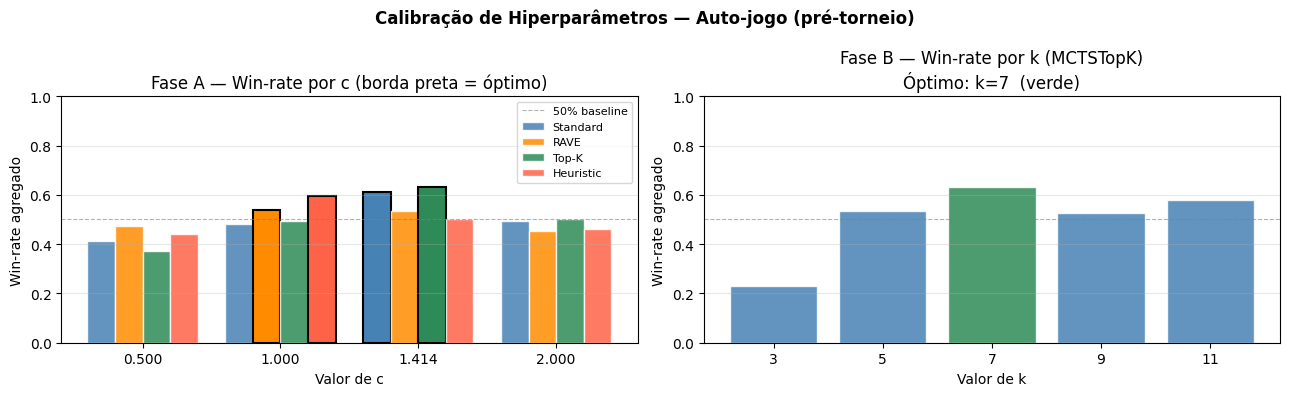

Calibração guardada → mcts_calibration.png

── Parâmetros finais para o torneio ──────────────────────
  Standard      c=1.4142
  RAVE          c=1.0000
  Top-K         c=1.4142  k=7
  Heuristic     c=1.0000


In [20]:
# ══════════════════════════════════════════════════════════════════════════
# 4.0  Calibração de hiperparâmetros por auto-jogo
#
#  Fase A — calibração do c (UCT exploration constant)
#            todas as estratégias, round-robin entre valores de c
#  Fase B — calibração do k (branching factor do MCTSTopK)
#            só MCTSTopK, usando o c óptimo encontrado na Fase A
# ══════════════════════════════════════════════════════════════════════════

from itertools import combinations

# ── Parâmetros de calibração ──────────────────────────────────────────────
C_VALUES    = [0.5, 1.0, math.sqrt(2), 2.0]   # candidatos a c
K_VALUES    = [3, 5, 7, 9, 11]                # candidatos a k (só Top-K)
N_CALIB     = 50    # jogos por par durante calibração
CALIB_ITER  = 200   # iterações MCTS durante calibração (mantém rapidez)


def _calib_run(factory_fn, n_games: int) -> Dict[str, int]:
    """
    Corre n_games usando dois agentes criados por factory_fn.
    Devolve {'wins_a1': int, 'wins_a2': int, 'draws': int}.
    Os primeiros n_games//2 jogos: factory_fn() é P1.
    Os restantes: factory_fn() é P2.
    """
    w1 = w2 = draws = 0
    half = n_games // 2
    for g in range(n_games):
        a1, a2 = factory_fn(), factory_fn()
        if g < half:
            res = run_game_detailed(a1, a2)
        else:
            res = run_game_detailed(a2, a1)
        w = res['winner']
        if w is None:   draws += 1
        elif w == 1:    w1    += 1
        else:           w2    += 1
    return {'wins_a1': w1, 'wins_a2': w2, 'draws': draws}


# ── Fase A: calibração do c ───────────────────────────────────────────────
print('=' * 62)
print('FASE A — Calibração do c (UCT exploration constant)')
print(f'  Valores testados : {[round(c,3) for c in C_VALUES]}')
print(f'  Jogos/par        : {N_CALIB}')
print(f'  Iterações/mov    : {CALIB_ITER}')
print('=' * 62)

strategy_classes = {
    'Standard'  : MCTS,
    'RAVE'      : MCTS_RAVE,
    'Top-K'     : MCTSTopK,
    'Heuristic' : MCTSWithHeuristics,
}

best_c: Dict[str, float] = {}
calib_c_results: Dict[str, Dict] = {}

for strat_name, cls in strategy_classes.items():
    print(f'\n  [{strat_name}]')
    scores  = {c: 0   for c in C_VALUES}
    totals  = {c: 0   for c in C_VALUES}

    for c1, c2 in combinations(C_VALUES, 2):
        # factories que diferem apenas no c
        if strat_name == 'Top-K':
            f1 = lambda c=c1: cls(iterations=CALIB_ITER, c=c, k=7)
            f2 = lambda c=c2: cls(iterations=CALIB_ITER, c=c, k=7)
        else:
            f1 = lambda c=c1: cls(iterations=CALIB_ITER, c=c)
            f2 = lambda c=c2: cls(iterations=CALIB_ITER, c=c)

        half = N_CALIB // 2
        w1 = w2 = draws = 0
        for g in range(N_CALIB):
            a1, a2 = f1(), f2()
            if g < half:
                res = run_game_detailed(a1, a2)
                w = res['winner']
                if w == 1:    w1 += 1
                elif w == 2:  w2 += 1
                else:         draws += 1
            else:
                res = run_game_detailed(a2, a1)
                w = res['winner']
                if w == 1:    w2 += 1
                elif w == 2:  w1 += 1
                else:         draws += 1

        scores[c1] += w1;  totals[c1] += N_CALIB
        scores[c2] += w2;  totals[c2] += N_CALIB

        pval = binomtest(w1, n=w1+w2, p=0.5).pvalue if (w1+w2) > 0 else 1.0
        sig  = '✓ sig' if pval < 0.05 else ''
        print(f'    c={c1:.3f} vs c={c2:.3f}  →  {w1}W / {w2}W / {draws}D  '
              f'(p={pval:.3f}) {sig}')

    win_rates = {c: scores[c] / max(totals[c], 1) for c in C_VALUES}
    opt_c     = max(win_rates, key=win_rates.get)
    best_c[strat_name] = opt_c
    calib_c_results[strat_name] = win_rates

    print(f'  Win-rates por c: '
          + '  '.join(f'c={c:.3f}→{wr:.3f}' for c, wr in win_rates.items()))
    print(f'  ★ Melhor c para {strat_name}: {opt_c:.4f}')

print('\n── Resumo Fase A ─────────────────────────────────────────')
for name, c in best_c.items():
    print(f'  {name:12s}  best c = {c:.4f}')


# ── Fase B: calibração do k (só MCTSTopK) ────────────────────────────────
print('\n' + '=' * 62)
print('FASE B — Calibração do k (MCTSTopK branching factor)')
print(f'  Valores testados : {K_VALUES}')
print(f'  c fixo           : {best_c["Top-K"]:.4f}  (resultado Fase A)')
print(f'  Jogos/par        : {N_CALIB}')
print('=' * 62)

opt_c_topk = best_c['Top-K']
k_scores   = {k: 0 for k in K_VALUES}
k_totals   = {k: 0 for k in K_VALUES}

for k1, k2 in combinations(K_VALUES, 2):
    f1 = lambda k=k1: MCTSTopK(iterations=CALIB_ITER, c=opt_c_topk, k=k)
    f2 = lambda k=k2: MCTSTopK(iterations=CALIB_ITER, c=opt_c_topk, k=k)

    half = N_CALIB // 2
    w1 = w2 = draws = 0
    for g in range(N_CALIB):
        a1, a2 = f1(), f2()
        if g < half:
            res = run_game_detailed(a1, a2)
            w = res['winner']
            if w == 1:    w1 += 1
            elif w == 2:  w2 += 1
            else:         draws += 1
        else:
            res = run_game_detailed(a2, a1)
            w = res['winner']
            if w == 1:    w2 += 1
            elif w == 2:  w1 += 1
            else:         draws += 1

    k_scores[k1] += w1;  k_totals[k1] += N_CALIB
    k_scores[k2] += w2;  k_totals[k2] += N_CALIB

    pval = binomtest(w1, n=w1+w2, p=0.5).pvalue if (w1+w2) > 0 else 1.0
    sig  = '✓ sig' if pval < 0.05 else ''
    print(f'  k={k1} vs k={k2}  →  {w1}W / {w2}W / {draws}D  '
          f'(p={pval:.3f}) {sig}')

k_win_rates = {k: k_scores[k] / max(k_totals[k], 1) for k in K_VALUES}
best_k      = max(k_win_rates, key=k_win_rates.get)

print('\nWin-rates por k: '
      + '  '.join(f'k={k}→{wr:.3f}' for k, wr in k_win_rates.items()))
print(f'★ Melhor k para MCTSTopK: {best_k}')


# ── Visualização dos resultados de calibração ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Gráfico A — win-rate por c, por estratégia
ax = axes[0]
c_labels = [f'{c:.3f}' for c in C_VALUES]
x = np.arange(len(C_VALUES))
width = 0.2
colors_strat = ['steelblue', 'darkorange', 'seagreen', 'tomato']
for i, (name, wr_dict) in enumerate(calib_c_results.items()):
    wrs = [wr_dict[c] for c in C_VALUES]
    bars = ax.bar(x + i * width, wrs, width, label=name,
                  color=colors_strat[i], edgecolor='white', alpha=0.85)
    # marcar o melhor
    opt_idx = C_VALUES.index(best_c[name])
    ax.bar(x[opt_idx] + i * width, wrs[opt_idx], width,
           color=colors_strat[i], edgecolor='black', linewidth=1.5, alpha=1.0)

ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='50% baseline')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(c_labels)
ax.set_xlabel('Valor de c')
ax.set_ylabel('Win-rate agregado')
ax.set_title('Fase A — Win-rate por c (borda preta = óptimo)')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1)

# Gráfico B — win-rate por k (MCTSTopK)
ax2 = axes[1]
k_labels = [str(k) for k in K_VALUES]
wrs_k    = [k_win_rates[k] for k in K_VALUES]
bar_colors = ['seagreen' if k == best_k else 'steelblue' for k in K_VALUES]
ax2.bar(k_labels, wrs_k, color=bar_colors, edgecolor='white', alpha=0.85)
ax2.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax2.set_xlabel('Valor de k')
ax2.set_ylabel('Win-rate agregado')
ax2.set_title(f'Fase B — Win-rate por k (MCTSTopK)\nÓptimo: k={best_k}  (verde)')
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, 1)

plt.suptitle('Calibração de Hiperparâmetros — Auto-jogo (pré-torneio)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('mcts_calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print('Calibração guardada → mcts_calibration.png')

print('\n── Parâmetros finais para o torneio ──────────────────────')
for name in strategy_classes:
    extra = f'  k={best_k}' if name == 'Top-K' else ''
    print(f'  {name:12s}  c={best_c[name]:.4f}{extra}')


In [11]:
# ── Configuração global do torneio ────────────────────────────────────────
# Os valores de c e k usados aqui são os encontrados pela calibração (secção 4.0).
# Se a calibração ainda não correu, os defaults abaixo são usados como fallback.

N_GAMES         = 200   # jogos por par
ITERATIONS      = 250   # iterações MCTS por movimento
MOVE_TIME_LIMIT = 2.0   # segundos máximos por jogada (hard cap)

# Fallback caso a calibração não tenha corrido
_fallback_c = {
    'Standard'  : 1.4142,
    'RAVE'      : 1.0000,
    'Top-K'     : 1.4142,
    'Heuristic' : 1.0000,
}
_default_k = 7

# Ler resultados da calibração (se disponíveis)
_best_c = globals().get('best_c', {})   # dict nome→c óptimo
_best_k = globals().get('best_k', _default_k)

def _get_c(name: str) -> float:
    return _best_c.get(name, _fallback_c.get(name, math.sqrt(2)))


def make_strategies() -> dict:
    """Cria um conjunto NOVO de agentes com os hiperparâmetros calibrados."""
    return {
        'Standard'  : MCTS(iterations=ITERATIONS, time_limit=MOVE_TIME_LIMIT, c=_get_c('Standard')),
        'RAVE'      : MCTS_RAVE(iterations=ITERATIONS, time_limit=MOVE_TIME_LIMIT, c=_get_c('RAVE')),
        'Top-K'     : MCTSTopK(iterations=ITERATIONS, time_limit=MOVE_TIME_LIMIT, c=_get_c('Top-K'), k=_best_k),
        'Heuristic' : MCTSWithHeuristics(iterations=ITERATIONS, time_limit=MOVE_TIME_LIMIT, c=_get_c('Heuristic')),
    }


strategy_factories = {
    'Standard'  : lambda: MCTS(iterations=ITERATIONS, time_limit=MOVE_TIME_LIMIT, c=_get_c('Standard')),
    'RAVE'      : lambda: MCTS_RAVE(iterations=ITERATIONS, time_limit=MOVE_TIME_LIMIT, c=_get_c('RAVE')),
    'Top-K'     : lambda: MCTSTopK(iterations=ITERATIONS, time_limit=MOVE_TIME_LIMIT, c=_get_c('Top-K'), k=_best_k),
    'Heuristic' : lambda: MCTSWithHeuristics(iterations=ITERATIONS, time_limit=MOVE_TIME_LIMIT, c=_get_c('Heuristic')),
}

strategies = make_strategies()

print('Parâmetros aplicados ao torneio:')
for name in strategy_factories:
    extra = f'  k={_best_k}' if name == 'Top-K' else ''
    print(f'  {name:12s}  c={_get_c(name):.4f}{extra}')
print(f'  N_GAMES={N_GAMES}  ITERATIONS={ITERATIONS}  MOVE_TIME_LIMIT={MOVE_TIME_LIMIT}s')

Parâmetros aplicados ao torneio:
  Standard      c=1.4142
  RAVE          c=1.0000
  Top-K         c=1.4142  k=7
  Heuristic     c=1.0000
  N_GAMES=200  ITERATIONS=250  MOVE_TIME_LIMIT=2.0s


#### 4.1.2 Warm-up

In [12]:
# Este bloco aquece todos os agentes com 1 jogada descartada,
# tornando as métricas de tempo do torneio mais representativas.

def warmup_agents(strategy_factories: dict) -> None:
    """Executa 1 choose_move descartado por agente para estabilizar tempos."""
    dummy = PopOutGame(rows=6, cols=7)
    dummy.make_move('drop', 3)    # estado ligeiramente não-vazio
    for name, factory in strategy_factories.items():
        agent = factory()
        _ = agent.choose_move(dummy)   # descartado
        print(f'  warm-up: {name} ✓')


#### 4.2 Tournament between the different MCTS Strategies

In [13]:
# ══════════════════════════════════════════════════════════════════════════
# 4.2  Torneio paralelizado — ProcessPoolExecutor
#
#  PORQUÊ tournament_worker.py e não função inline?
#    No Windows, multiprocessing usa 'spawn': cada worker importa o módulo
#    onde a função worker está definida. Se estiver em __main__ (Jupyter),
#    o worker tenta importar o kernel → crash imediato.
#    tournament_worker.py é um módulo regular: workers importam-no sem
#    qualquer dependência do notebook ou dos seus globals.
# ══════════════════════════════════════════════════════════════════════════

import os
import sys
import importlib
from concurrent.futures import ProcessPoolExecutor, as_completed

try:
    from tqdm.auto import tqdm as _tqdm
    _HAS_TQDM = True
except ImportError:
    _HAS_TQDM = False
    print('[aviso] tqdm nao instalado — sem barra de progresso.')

# i9-12900KF: 8 P-cores + 8 E-cores = 16 físicos / 24 lógicos
# Para CPU-bound Python, o óptimo é ~nº de cores físicos (não HT).
# Limitar a 12 evita OOM e contenção; os P-cores ficam ocupados.
N_WORKERS = min(max(1, os.cpu_count() - 2), 12)
print(f'Workers: {N_WORKERS}  (de {os.cpu_count()} logicos)')

# Importar worker de módulo externo — reload garante que edições são captadas
import tournament_worker as _tw
importlib.reload(_tw)
from tournament_worker import run_one_game

print(f'Worker module: {_tw.__file__}')


# ── Config dict por estratégia — serializable sem globals do notebook ─────
def _make_cfg(name: str) -> dict:
    cfg = {
        'strategy':   name,
        'c':          _get_c(name),
        'iterations': ITERATIONS,
        'time_limit': MOVE_TIME_LIMIT,
    }
    if name == 'Top-K':
        cfg['k'] = _best_k
    return cfg

AGENT_CFGS = {name: _make_cfg(name) for name in strategy_factories}

print('Parâmetros capturados nas configs:')
for name, cfg in AGENT_CFGS.items():
    extra = f'  k={cfg["k"]}' if 'k' in cfg else ''
    print(f'  {name:12s}  c={cfg["c"]:.4f}{extra}  itr={cfg["iterations"]}  tlim={cfg["time_limit"]}s')


# ── run_tournament_parallel ───────────────────────────────────────────────
def run_tournament_parallel(agent_cfgs, n_games=N_GAMES,
                             n_workers=N_WORKERS, seed_base=42):
    names = list(agent_cfgs.keys())
    pairs = [(n1, n2) for i, n1 in enumerate(names) for n2 in names[i + 1:]]

    tasks = []
    gidx  = 0
    for n1, n2 in pairs:
        half = n_games // 2
        for g in range(n_games):
            tasks.append({
                'n1': n1, 'n2': n2,
                'cfg1': agent_cfgs[n1],
                'cfg2': agent_cfgs[n2],
                'gi': g, 'half': half,
                'seed': seed_base + gidx,
            })
            gidx += 1

    print(f'  {len(tasks)} jogos totais  |  {n_workers} workers')

    acc = {(n1, n2): {
        'a1w': 0, 'a2w': 0, 'dr': 0,
        'a1t': [], 'a2t': [], 'gl': [],
        'a1p': 0,  'a2p': 0,
        'a1pw': 0, 'a2pw': 0,
        'a1pl': 0, 'a2pl': 0,
        'a1m': 0,  'a2m': 0,
        'a1mw': 0, 'a1ml': 0,
        'a1e': [], 'a2e': [],
    } for n1, n2 in pairs}

    prog = _tqdm(total=len(tasks), desc='Torneio', unit='jogo') \
           if _HAS_TQDM else None

    with ProcessPoolExecutor(max_workers=n_workers) as ex:
        futs = {ex.submit(run_one_game, t): t for t in tasks}
        for fut in as_completed(futs):
            try:
                r = fut.result()
            except Exception as exc:
                t = futs[fut]
                print(f'  [ERRO] {t["n1"]} vs {t["n2"]} '
                      f'jogo {t["gi"]}: {exc}', file=sys.stderr)
                if prog: prog.update(1)
                continue

            d = acc[r['pair']]
            if r['result'] == 'a1_win':
                d['a1w']  += 1
                d['a1pw'] += r['a1pw']
                d['a1mw'] += r['a1m']
            elif r['result'] == 'a2_win':
                d['a2w']  += 1
                d['a2pw'] += r['a2pw']
                d['a1ml'] += r['a1m']
            else:
                d['dr']   += 1

            d['a1p']  += r['a1p'];  d['a2p']  += r['a2p']
            d['a1pl'] += r['a1p'] - r['a1pw']
            d['a2pl'] += r['a2p'] - r['a2pw']
            d['a1m']  += r['a1m'];  d['a2m']  += r['a2m']
            d['a1t'].extend(r['a1t']); d['a2t'].extend(r['a2t'])
            d['gl'].append(r['n_moves'])
            d['a1e'].extend(r['a1e']); d['a2e'].extend(r['a2e'])

            if prog: prog.update(1)

    if prog: prog.close()

    records = []
    for n1, n2 in pairs:
        d     = acc[(n1, n2)]
        total = d['a1w'] + d['a2w'] + d['dr']
        if total == 0:
            print(f'  [AVISO] {n1} vs {n2}: nenhum jogo completado.')
            continue
        a1pct   = round(d['a1p']  / max(d['a1m'],  1) * 100, 1)
        a2pct   = round(d['a2p']  / max(d['a2m'],  1) * 100, 1)
        a1pct_w = round(d['a1pw'] / max(d['a1mw'], 1) * 100, 1)
        a1pct_l = round(d['a1pl'] / max(d['a1ml'], 1) * 100, 1)
        print(f'  {n1:12s} vs {n2:12s}  '
              f'[{n1} {d["a1w"]}W  {n2} {d["a2w"]}W  {d["dr"]}D]')
        records.append({
            'A1': n1,  'A2': n2,
            'A1_wins': d['a1w'],  'A2_wins': d['a2w'],  'Draws': d['dr'],
            'A1_win%': round(d['a1w'] / total * 100, 1),
            'A2_win%': round(d['a2w'] / total * 100, 1),
            'Draw%'  : round(d['dr']  / total * 100, 1),
            'A1_ms'  : round(np.mean(d['a1t']), 1) if d['a1t'] else 0.0,
            'A2_ms'  : round(np.mean(d['a2t']), 1) if d['a2t'] else 0.0,
            'Avg_moves'  : round(np.mean(d['gl']), 1),
            'Moves_std'  : round(np.std(d['gl']),  1),
            'A1_pop%'    : a1pct,   'A2_pop%'    : a2pct,
            'A1_pop%_W'  : a1pct_w, 'A1_pop%_L'  : a1pct_l,
            'A1_entropy' : round(np.mean(d['a1e']), 3) if d['a1e'] else None,
            'A2_entropy' : round(np.mean(d['a2e']), 3) if d['a2e'] else None,
        })
    return pd.DataFrame(records)


# ── Execução ──────────────────────────────────────────────────────────────
print('\nWarm-up dos agentes...')
warmup_agents(strategy_factories)
print()

_t0 = time.time()
print(f'Tournament paralelo: {N_GAMES} jogos/par  |  '
      f'{ITERATIONS} iters/mov  |  {N_WORKERS} workers')
print('=' * 62)

df_tournament = run_tournament_parallel(
    AGENT_CFGS, n_games=N_GAMES, n_workers=N_WORKERS)

print(f'\nTorneio concluido em {(time.time() - _t0) / 60:.1f} min')

print('\n=== Full Results ===')
cols_show = ['A1', 'A2', 'A1_wins', 'A2_wins', 'Draws',
             'A1_win%', 'A2_win%', 'Draw%', 'A1_ms', 'A2_ms',
             'Avg_moves', 'Moves_std', 'A1_pop%', 'A2_pop%',
             'A1_pop%_W', 'A1_pop%_L', 'A1_entropy', 'A2_entropy']
print(df_tournament[cols_show].to_string(index=False))

print('\n=== Significância estatística (teste binomial) ===')
for _, row in df_tournament.iterrows():
    n   = row['A1_wins'] + row['A2_wins'] + row['Draws']
    res = binomtest(int(row['A1_wins']), n=int(n), p=0.5)
    sig = '✓ sig' if res.pvalue < 0.05 else '✗ n.s.'
    win = row['A1'] if row['A1_wins'] > row['A2_wins'] else \
          row['A2'] if row['A2_wins'] > row['A1_wins'] else 'empate'
    print(f"  {row['A1']:12s} vs {row['A2']:12s}  "
          f"p={res.pvalue:.3f}  {sig}  -> {win}")


Workers: 12  (de 24 logicos)
Worker module: c:\Users\Admin\Desktop\MCTS-Decision-Trees-main\tournament_worker.py
Parâmetros capturados nas configs:
  Standard      c=1.4142  itr=250  tlim=2.0s
  RAVE          c=1.0000  itr=250  tlim=2.0s
  Top-K         c=1.4142  k=7  itr=250  tlim=2.0s
  Heuristic     c=1.0000  itr=250  tlim=2.0s

Warm-up dos agentes...
  warm-up: Standard ✓
  warm-up: RAVE ✓
  warm-up: Top-K ✓
  warm-up: Heuristic ✓

Tournament paralelo: 200 jogos/par  |  250 iters/mov  |  12 workers
  1200 jogos totais  |  12 workers


Torneio:   0%|          | 0/1200 [00:00<?, ?jogo/s]

  Standard     vs RAVE          [Standard 113W  RAVE 87W  0D]
  Standard     vs Top-K         [Standard 91W  Top-K 109W  0D]
  Standard     vs Heuristic     [Standard 79W  Heuristic 121W  0D]
  RAVE         vs Top-K         [RAVE 80W  Top-K 120W  0D]
  RAVE         vs Heuristic     [RAVE 79W  Heuristic 121W  0D]
  Top-K        vs Heuristic     [Top-K 101W  Heuristic 99W  0D]

Torneio concluido em 37.8 min

=== Full Results ===
      A1        A2  A1_wins  A2_wins  Draws  A1_win%  A2_win%  Draw%  A1_ms  A2_ms  Avg_moves  Moves_std  A1_pop%  A2_pop%  A1_pop%_W  A1_pop%_L  A1_entropy  A2_entropy
Standard      RAVE      113       87      0     56.5     43.5    0.0  888.8  882.2       17.9        7.0      8.6      8.8        5.4       12.8       3.017       2.892
Standard     Top-K       91      109      0     45.5     54.5    0.0  888.7  869.2       17.2        6.9      8.1      6.3        4.8       11.1       3.001       2.688
Standard Heuristic       79      121      0     39.5     60.5 

#### 4.3 MCTS Convergence Analysis


=== Análise de Convergência ===
  Convergence probe: Standard (4 games)... done  [avg_sims=250  entropy=3.059  → High]
  Convergence probe: RAVE (4 games)... done  [avg_sims=250  entropy=2.907  → High]
  Convergence probe: Top-K (4 games)... done  [avg_sims=248  entropy=2.706  → High]
  Convergence probe: Heuristic (4 games)... done  [avg_sims=223  entropy=2.562  → High]
           Avg_sims  Avg_entropy  Avg_children Convergence
Strategy                                                  
Standard      250.0        3.059           9.0        High
RAVE          250.0        2.907           8.8        High
Top-K         248.4        2.706           7.0        High
Heuristic     223.2        2.562           7.2        High


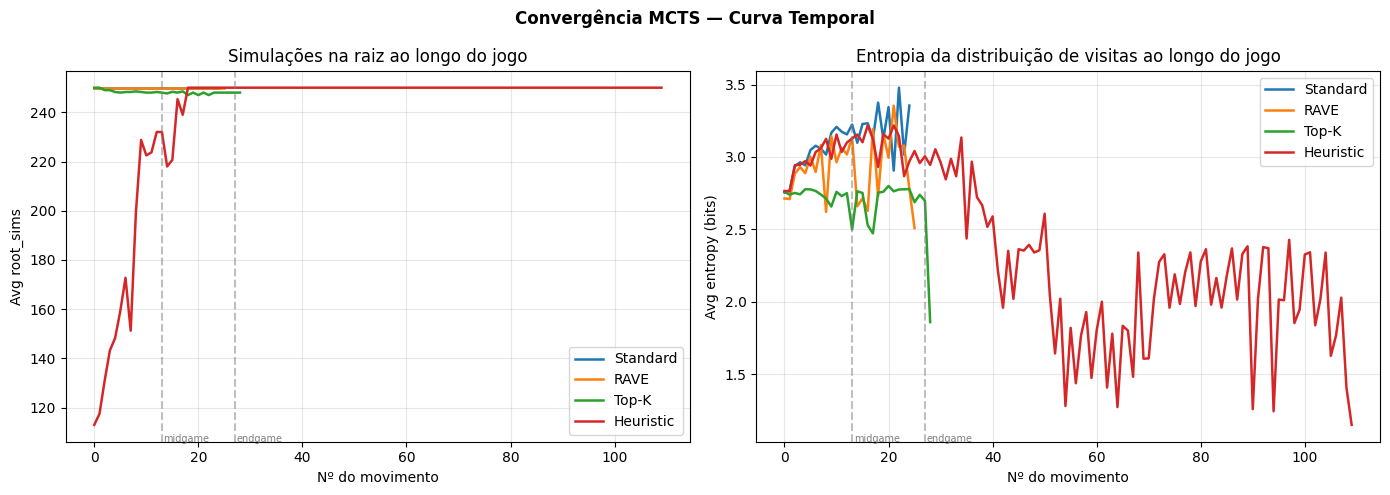

Curva temporal guardada → mcts_convergence_temporal.png


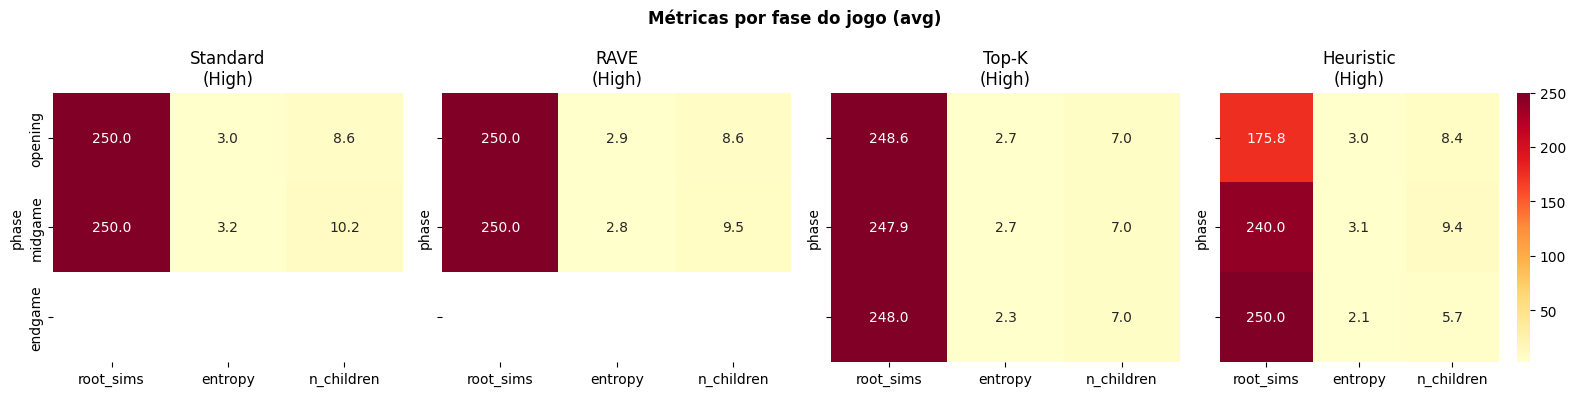

Heatmaps por fase guardados → mcts_phase_heatmaps.png


In [14]:
def convergence_analysis(
    
strategy_factories: dict,   
# era: strategies: dict
    n_diagnostic_games: int = 4,
) -> pd.DataFrame:
    """
    Correcções aplicadas:
      [C1] Dois agentes independentes por jogo (era o mesmo objecto
           a jogar contra si próprio — self.root partilhado)
      [C2] Trim do 1º movimento nos tempos, consistente com torneio
      [C3] Aceita factories em vez de instâncias
    """
    results = {}

    for name, factory in strategy_factories.items():
        print(f'  Convergence probe: {name} ({n_diagnostic_games} games)...',
              end=' ', flush=True)
        all_logs = []

        for _ in range(n_diagnostic_games):
            # [C1] dois objectos distintos — raízes MCTS independentes
            agent_p1 = factory()
            agent_p2 = factory()
            res = run_game_detailed(agent_p1, agent_p2)
            all_logs.extend(res['move_log'])

        df_log = pd.DataFrame(all_logs)
        df_log = df_log.dropna(subset=['root_sims', 'entropy'])

        avg_sims     = df_log['root_sims'].mean()
        avg_entropy  = df_log['entropy'].mean()
        avg_children = df_log['n_children'].mean()

        # Classificação de convergência (calibrada para 200 iter / PopOut 6×7)
        if avg_sims >= 180:   convergence = 'High'
        elif avg_sims >= 120: convergence = 'Moderate'
        else:                 convergence = 'Low'

        phase_stats = (
            df_log.groupby('phase')[['root_sims', 'entropy', 'n_children']]
            .mean().round(2)
        )
        temporal = (
            df_log.groupby('move_number')[['root_sims', 'entropy']].mean()
        )

        results[name] = {
            'avg_sims'    : round(avg_sims,    1),
            'avg_entropy' : round(avg_entropy, 3),
            'avg_children': round(avg_children,1),
            'convergence' : convergence,
            'phase_stats' : phase_stats,
            'temporal'    : temporal,
        }
        print(f'done  [avg_sims={avg_sims:.0f}  entropy={avg_entropy:.3f}  → {convergence}]')

    summary = pd.DataFrame([
        {
            'Strategy'    : name,
            'Avg_sims'    : v['avg_sims'],
            'Avg_entropy' : v['avg_entropy'],
            'Avg_children': v['avg_children'],
            'Convergence' : v['convergence'],
        }
        for name, v in results.items()
    ]).set_index('Strategy')

    return summary, results


# ── Execução ──────────────────────────────────────────────────────────────
print('\n=== Análise de Convergência ===')
df_convergence, conv_details = convergence_analysis(
    strategy_factories, n_diagnostic_games=4
)
print(df_convergence.to_string())
 
 
# ── Plot: curva de convergência temporal ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.tab10.colors
 
for idx, (name, detail) in enumerate(conv_details.items()):
    t = detail['temporal']
    c = colors[idx % len(colors)]
    axes[0].plot(t.index, t['root_sims'], label=name, color=c, linewidth=1.8)
    axes[1].plot(t.index, t['entropy'],   label=name, color=c, linewidth=1.8)
 
axes[0].set_title('Simulações na raiz ao longo do jogo')
axes[0].set_xlabel('Nº do movimento'); axes[0].set_ylabel('Avg root_sims')
axes[0].legend(); axes[0].grid(alpha=.3)
 
axes[1].set_title('Entropia da distribuição de visitas ao longo do jogo')
axes[1].set_xlabel('Nº do movimento'); axes[1].set_ylabel('Avg entropy (bits)')
axes[1].legend(); axes[1].grid(alpha=.3)
 
for ax in axes:
    for x, label in [(13, 'midgame'), (27, 'endgame')]:
        ax.axvline(x=x, color='gray', linestyle='--', alpha=.5)
        ax.text(x+0.3, ax.get_ylim()[0], label, fontsize=7, color='gray')
 
plt.suptitle('Convergência MCTS — Curva Temporal', fontweight='bold')
plt.tight_layout()
plt.savefig('mcts_convergence_temporal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Curva temporal guardada → mcts_convergence_temporal.png')
 
 
# ── Plot: by-phase heatmaps ───────────────────────────────────────────────
fig, axes = plt.subplots(1, len(conv_details), figsize=(4 * len(conv_details), 4),
                         sharey=True)
for ax, (name, detail) in zip(axes, conv_details.items()):
    ps = detail['phase_stats'].reindex(['opening','midgame','endgame'])
    sns.heatmap(ps, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
                cbar=(ax == axes[-1]))
    ax.set_title(f'{name}\n({df_convergence.loc[name,"Convergence"]})')
    ax.set_xlabel('')
plt.suptitle('Métricas por fase do jogo (avg)', fontweight='bold')
plt.tight_layout()
plt.savefig('mcts_phase_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmaps por fase guardados → mcts_phase_heatmaps.png')


#### 4.4 Log 

In [15]:
# ══════════════════════════════════════════════════════════════════════════
# 4.4  Log de jogo verbose  —  exemplo de partida diagnóstica
#      Inclui modo errors_only para identificar falhas tácticas
# ══════════════════════════════════════════════════════════════════════════
 
def demo_game_verbose(agent1, agent2, name1: str, name2: str,
                      mode: str = 'full'):
    """
    Corre um jogo de demonstração e imprime o log detalhado.
 
    mode='full'        → imprime cada movimento
    mode='errors_only' → só imprime quando chosen_wr < 0.50
    """
    print(f'\n{"="*62}')
    print(f' Demo game: {name1} (P1)  vs  {name2} (P2)')
    print(f' Verbose mode: {mode}')
    print(f'{"="*62}')
 
    verbose        = (mode == 'full')
    errors_only    = (mode == 'errors_only')
 
    res = run_game_detailed(agent1, agent2,
                            verbose=verbose,
                            verbose_errors_only=errors_only)
 
    winner_str = f'Player {res["winner"]}' if res['winner'] else 'Draw'
    print(f'\n── Resultado: {winner_str}  ({res["n_moves"]} movimentos) ──')
    print(f'   P1 pops: {res["p1_pops"]}  |  P2 pops: {res["p2_pops"]}')
 
    # Tabela resumo do log
    df_log = pd.DataFrame(res['move_log'])
    if not df_log.empty:
        weak_moves = df_log[df_log['chosen_wr'].lt(0.50).fillna(False)]
        print(f'\n   Movimentos com chosen_wr < 0.50: {len(weak_moves)}')
        if not weak_moves.empty:
            print(weak_moves[['move_number','player','move_type','col',
                              'phase','chosen_wr','entropy']].to_string(index=False))
    return res
 
 
# Demonstração: Heuristic vs RAVE em modo errors_only
_ = demo_game_verbose(
    strategies['Heuristic'], strategies['RAVE'],
    'Heuristic', 'RAVE',
    mode='errors_only',
)



 Demo game: Heuristic (P1)  vs  RAVE (P2)
 Verbose mode: errors_only

── Move   7  P2  DROP col 3  [opening]  ⚠ WEAK
   sims=  250  children= 7  best_visit_wr=0.386  chosen_wr=0.386  entropy=2.789

── Resultado: Player 1  (9 movimentos) ──
   P1 pops: 0  |  P2 pops: 1

   Movimentos com chosen_wr < 0.50: 1
 move_number  player move_type  col   phase  chosen_wr  entropy
           7       2      drop    3 opening     0.3864   2.7891


#### 4.5 Visual Dashboard

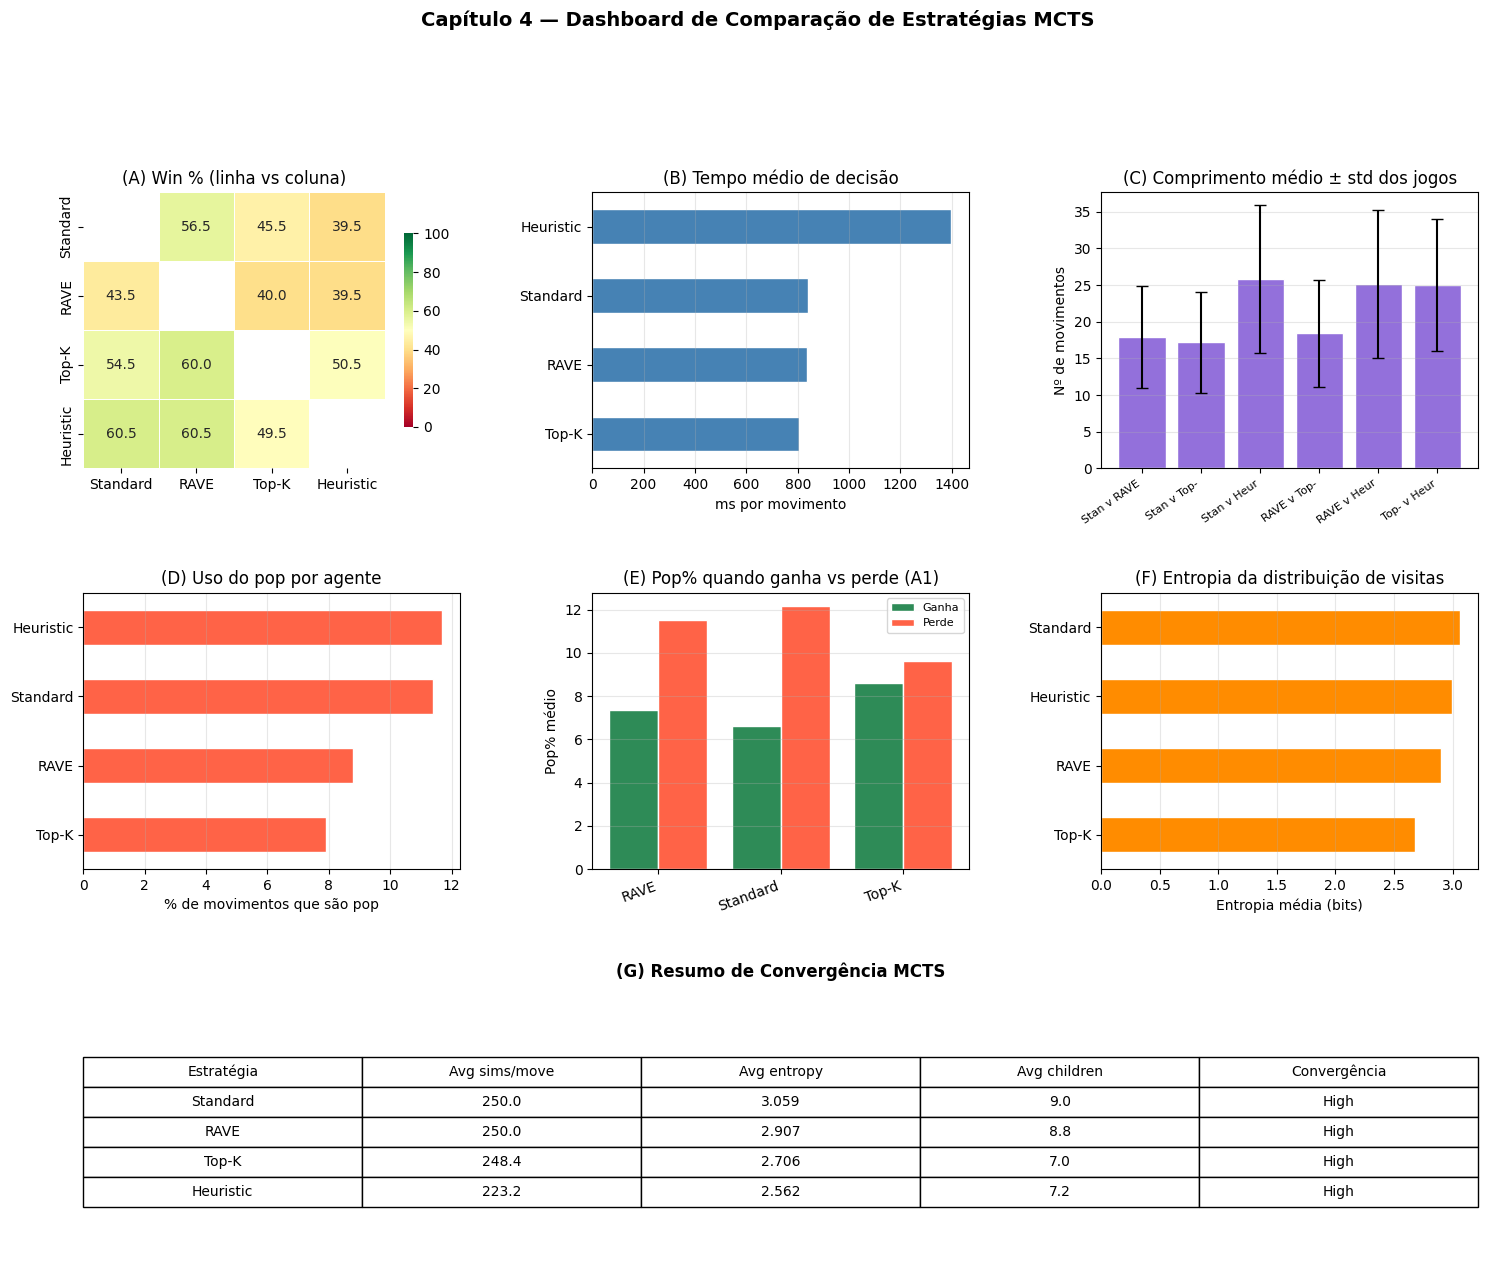

Dashboard guardado → mcts_dashboard.png


In [16]:
agent_names = list(strategies.keys())
n_agents    = len(agent_names)
 
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
 
# ── (A) Win-rate heatmap ─────────────────────────────────────────────────
ax_win = fig.add_subplot(gs[0, 0])
win_matrix = pd.DataFrame(np.full((n_agents, n_agents), np.nan),
                           index=agent_names, columns=agent_names)
for _, row in df_tournament.iterrows():
    win_matrix.loc[row['A1'], row['A2']] = row['A1_win%']
    win_matrix.loc[row['A2'], row['A1']] = row['A2_win%']
sns.heatmap(win_matrix.astype(float), annot=True, fmt='.1f',
            cmap='RdYlGn', vmin=0, vmax=100, linewidths=.5,
            ax=ax_win, cbar_kws={'shrink': .7})
ax_win.set_title('(A) Win % (linha vs coluna)')
 
# ── (B) Tempo médio por agente ──────────────────────────────────────────
ax_time = fig.add_subplot(gs[0, 1])
time_data = defaultdict(list)
for _, row in df_tournament.iterrows():
    time_data[row['A1']].append(row['A1_ms'])
    time_data[row['A2']].append(row['A2_ms'])
avg_times = {ag: np.mean(v) for ag, v in time_data.items()}
pd.Series(avg_times).sort_values().plot(
    kind='barh', ax=ax_time, color='steelblue', edgecolor='white')
ax_time.set_xlabel('ms por movimento')
ax_time.set_title('(B) Tempo médio de decisão')
ax_time.grid(axis='x', alpha=.3)
 
# ── (C) Avg_moves ± std por par ─────────────────────────────────────────
ax_len = fig.add_subplot(gs[0, 2])
pairs  = [f'{r.A1[:4]} v {r.A2[:4]}' for _, r in df_tournament.iterrows()]
ax_len.bar(pairs, df_tournament['Avg_moves'],
           yerr=df_tournament['Moves_std'], capsize=4,
           color='mediumpurple', edgecolor='white')
ax_len.set_ylabel('Nº de movimentos')
ax_len.set_title('(C) Comprimento médio ± std dos jogos')
ax_len.set_xticklabels(pairs, rotation=35, ha='right', fontsize=8)
ax_len.grid(axis='y', alpha=.3)
 
# ── (D) Pop% por agente (global) ─────────────────────────────────────────
ax_pop = fig.add_subplot(gs[1, 0])
pop_a1 = dict(zip(df_tournament['A1'], df_tournament['A1_pop%']))
pop_a2 = dict(zip(df_tournament['A2'], df_tournament['A2_pop%']))
pop_all = defaultdict(list)
for k, v in {**pop_a1, **pop_a2}.items():
    pop_all[k].append(v)
pop_means = {k: np.mean(v) for k, v in pop_all.items()}
pd.Series(pop_means).sort_values().plot(
    kind='barh', ax=ax_pop, color='tomato', edgecolor='white')
ax_pop.set_xlabel('% de movimentos que são pop')
ax_pop.set_title('(D) Uso do pop por agente')
ax_pop.grid(axis='x', alpha=.3)
 
# ── (E) Pop%_W vs Pop%_L  (só para A1) ──────────────────────────────────
ax_popwl = fig.add_subplot(gs[1, 1])
df_popwl = df_tournament[['A1','A1_pop%_W','A1_pop%_L']].copy()
df_popwl = df_popwl.groupby('A1')[['A1_pop%_W','A1_pop%_L']].mean()
x_pos = np.arange(len(df_popwl))
ax_popwl.bar(x_pos - 0.2, df_popwl['A1_pop%_W'], 0.4,
             label='Ganha', color='seagreen', edgecolor='white')
ax_popwl.bar(x_pos + 0.2, df_popwl['A1_pop%_L'], 0.4,
             label='Perde', color='tomato',   edgecolor='white')
ax_popwl.set_xticks(x_pos)
ax_popwl.set_xticklabels(df_popwl.index, rotation=20, ha='right')
ax_popwl.set_ylabel('Pop% médio')
ax_popwl.set_title('(E) Pop% quando ganha vs perde (A1)')
ax_popwl.legend(fontsize=8)
ax_popwl.grid(axis='y', alpha=.3)
 
# ── (F) Entropia média por agente ────────────────────────────────────────
ax_ent = fig.add_subplot(gs[1, 2])
ent_a1 = dict(zip(df_tournament['A1'], df_tournament['A1_entropy']))
ent_a2 = dict(zip(df_tournament['A2'], df_tournament['A2_entropy']))
ent_all = defaultdict(list)
for d in [ent_a1, ent_a2]:
    for k, v in d.items():
        if v is not None:
            ent_all[k].append(v)
ent_means = {k: np.mean(v) for k, v in ent_all.items()}
pd.Series(ent_means).sort_values().plot(
    kind='barh', ax=ax_ent, color='darkorange', edgecolor='white')
ax_ent.set_xlabel('Entropia média (bits)')
ax_ent.set_title('(F) Entropia da distribuição de visitas')
ax_ent.grid(axis='x', alpha=.3)
 
# ── (G) Tabela de convergência ───────────────────────────────────────────
ax_conv = fig.add_subplot(gs[2, :])
ax_conv.axis('off')
tbl_data = df_convergence.reset_index()
tbl_data.columns = ['Estratégia','Avg sims/move','Avg entropy','Avg children','Convergência']
colors_conv = []
for row in tbl_data.itertuples():
    c = {'High':'#c8e6c9','Moderate':'#fff9c4','Low':'#ffcdd2'}.get(row[4], 'white')
    colors_conv.append([c]*5)
table = ax_conv.table(
    cellText=tbl_data.values,
    colLabels=tbl_data.columns,
    cellLoc='center', loc='center',
    cellColours=colors_conv,
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8)
ax_conv.set_title('(G) Resumo de Convergência MCTS', pad=12, fontweight='bold')
 
plt.suptitle('Capítulo 4 — Dashboard de Comparação de Estratégias MCTS',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('mcts_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard guardado → mcts_dashboard.png')

## 5. Decision Tree Implementation

Train a Decision Tree to learn optimal strategies from game data.

In [17]:
# ══════════════════════════════════════════════════════════════════════════
# 5.1  State encoding helpers
# ══════════════════════════════════════════════════════════════════════════

FEATURE_NAMES = (
    [f'r{r}c{c}' for r in range(6) for c in range(7)]  # 42 board cells
    + ['current_player']                                 # whose turn
)
N_ACTIONS = 14  # 7 drop + 7 pop

def encode_move(move: Tuple[str, int]) -> int:
    """Encode (type, col) → integer label 0-13.
    drop col c → c      (0-6)
    pop  col c → c + 7  (7-13)
    """
    mtype, col = move
    return col if mtype == 'drop' else col + 7

def decode_move(label: int) -> Tuple[str, int]:
    """Inverse of encode_move."""
    return ('drop', label) if label < 7 else ('pop', label - 7)

def state_to_features(game: PopOutGame) -> List[int]:
    """Flat feature vector: 42 board cells (0/1/2) + current_player (1/2)."""
    return list(game.board.flatten().astype(int)) + [game.current_player]

print(f"Feature vector length : {len(FEATURE_NAMES)}")
print(f"Action space size     : {N_ACTIONS}  (0-6 drop, 7-13 pop)")
print(f"Example encoding      : drop col 3 → {encode_move(('drop',3))}, "
      f"pop col 3 → {encode_move(('pop',3))}")


Feature vector length : 43
Action space size     : 14  (0-6 drop, 7-13 pop)
Example encoding      : drop col 3 → 3, pop col 3 → 10


### 5.2  Dataset Generation

After the tournament the **winning MCTS variant** is identified from `df_tournament` and used to label every position. Each self-play game produces one `(state, best_MCTS_move)` pair per half-move. Both players are driven by the same agent so the dataset covers positions from both sides of the board.


In [18]:
# ── Identify the winning MCTS from tournament results ────────────────────
mcts_names  = ['Standard', 'RAVE', 'Top-K', 'Heuristic']
mcts_scores = {ag: 0 for ag in mcts_names}

for _, row in df_tournament.iterrows():
    a1, a2 = row['A1'], row['A2']
    if a1 in mcts_names and a2 in mcts_names:
        mcts_scores[a1] += row['A1_wins']
        mcts_scores[a2] += row['A2_wins']

best_mcts_name = max(mcts_scores, key=mcts_scores.get)

print("MCTS win counts (inter-MCTS games only):")
for ag, sc in sorted(mcts_scores.items(), key=lambda x: -x[1]):
    print(f"  {ag:12s}  {sc} wins")
print(f"\nTournament winner -> {best_mcts_name}")

# ── Configuration ────────────────────────────────────────────────────────
N_DATASET_GAMES = 200   # self-play games to generate the dataset
MCTS_ITER_DATA  = 200   # MCTS iterations per move during generation
#   200 iter x ~30 moves/game x 200 games ~= 1.2 M simulations total.

# ── Build the data agent from the tournament winner ───────────────────────
_data_agent_map = {
    'Standard'  : MCTS,
    'RAVE'      : MCTS_RAVE,
    'Top-K'     : MCTSTopK,
    'Heuristic' : MCTSWithHeuristics,
}
data_agent = _data_agent_map[best_mcts_name](iterations=MCTS_ITER_DATA)
print(f"Data agent : {best_mcts_name}  ({MCTS_ITER_DATA} iterations/move)\n")

# ── Collection loop ───────────────────────────────────────────────────────
import time as _time

X_raw: List[List[int]] = []
y_raw: List[int]       = []

t0 = _time.time()
for g_idx in range(N_DATASET_GAMES):
    game = PopOutGame(rows=6, cols=7)
    while not game.game_over:
        # Record (state, best-MCTS move) BEFORE applying the move
        features = state_to_features(game)
        move     = data_agent.choose_move(game)
        if move is None:
            break

        # Draw actions do not belong to the 14-class DT label space.
        if move[0] == 'draw':
            game.make_move(move[0], move[1])
            continue

        X_raw.append(features)
        y_raw.append(encode_move(move))
        game.make_move(move[0], move[1])
    if (g_idx + 1) % 20 == 0:
        elapsed = _time.time() - t0
        print(f"  Game {g_idx+1:>3}/{N_DATASET_GAMES}  "
              f"| samples so far: {len(X_raw):>5}  "
              f"| elapsed: {elapsed:.1f}s")

print(f"\nDataset generated: {len(X_raw)} samples from {N_DATASET_GAMES} games")
print(f"Total time: {_time.time()-t0:.1f}s")


MCTS win counts (inter-MCTS games only):
  Heuristic     341 wins
  Top-K         330 wins
  Standard      283 wins
  RAVE          246 wins

Tournament winner -> Heuristic
Data agent : Heuristic  (200 iterations/move)

  Game  20/200  | samples so far:  1165  | elapsed: 1093.2s
  Game  40/200  | samples so far:  2653  | elapsed: 2520.6s
  Game  60/200  | samples so far:  3646  | elapsed: 3479.0s
  Game  80/200  | samples so far:  4570  | elapsed: 4347.7s
  Game 100/200  | samples so far:  5712  | elapsed: 5398.2s
  Game 120/200  | samples so far:  7007  | elapsed: 6548.9s
  Game 140/200  | samples so far:  8295  | elapsed: 7770.8s
  Game 160/200  | samples so far:  9281  | elapsed: 8677.3s
  Game 180/200  | samples so far: 10327  | elapsed: 9678.8s
  Game 200/200  | samples so far: 12320  | elapsed: 11706.8s

Dataset generated: 12320 samples from 200 games
Total time: 11706.8s


In [25]:

# ══════════════════════════════════════════════════════════════════════════
# 5.2b  Save dataset to CSV
#
# Format: one row per (state_i, move_i) pair
#   - 42 board-cell features (r0c0 … r5c6) : int {0, 1, 2}
#   - current_player                        : int {1, 2}
#   - action                                : int {0-13}
#                                             0-6  → drop column 0-6
#                                             7-13 → pop  column 0-6
#   - move_type                             : str  {'drop', 'pop'}
#   - col                                   : int  {0-6}
#   - mcts_agent                            : str  name of the agent that
#                                             generated this label
# ══════════════════════════════════════════════════════════════════════════

import pandas as pd
import os

_CSV_PATH = os.path.join(os.getcwd(), "popout_mcts_dataset.csv")

# Build DataFrame ─────────────────────────────────────────────────────────
_X_arr = [row[:42] for row in X_raw]            # 42 board cells
_cp    = [row[42]  for row in X_raw]            # current_player

df_csv = pd.DataFrame(_X_arr, columns=FEATURE_NAMES[:42])
df_csv['current_player'] = _cp
df_csv['action']         = y_raw
df_csv['move_type']      = [decode_move(int(a))[0] for a in y_raw]
df_csv['col']            = [decode_move(int(a))[1] for a in y_raw]
df_csv['mcts_agent']     = best_mcts_name        # which MCTS generated this

# Save ────────────────────────────────────────────────────────────────────
df_csv.to_csv(_CSV_PATH, index=False)

print(f"Dataset saved  →  {_CSV_PATH}")
print(f"  Rows    : {len(df_csv)}")
print(f"  Columns : {list(df_csv.columns)}")
print(f"  Agent   : {best_mcts_name}  ({MCTS_ITER_DATA} iters/move)")
print(f"\nColumn layout:")
print(f"  board features  : r0c0 … r5c6  (42 cols, values {{0,1,2}})")
print(f"  current_player  : 1 or 2")
print(f"  action          : 0-6 = drop col 0-6 | 7-13 = pop col 0-6")
print(f"  move_type / col : human-readable version of action")
print(f"  mcts_agent      : MCTS variant that labelled the data")
print(f"\nFirst 3 rows:")
print(df_csv.head(3).to_string())


Dataset saved  →  c:\Users\Admin\Desktop\MCTS-Decision-Trees-main\popout_mcts_dataset.csv
  Rows    : 12320
  Columns : ['r0c0', 'r0c1', 'r0c2', 'r0c3', 'r0c4', 'r0c5', 'r0c6', 'r1c0', 'r1c1', 'r1c2', 'r1c3', 'r1c4', 'r1c5', 'r1c6', 'r2c0', 'r2c1', 'r2c2', 'r2c3', 'r2c4', 'r2c5', 'r2c6', 'r3c0', 'r3c1', 'r3c2', 'r3c3', 'r3c4', 'r3c5', 'r3c6', 'r4c0', 'r4c1', 'r4c2', 'r4c3', 'r4c4', 'r4c5', 'r4c6', 'r5c0', 'r5c1', 'r5c2', 'r5c3', 'r5c4', 'r5c5', 'r5c6', 'current_player', 'action', 'move_type', 'col', 'mcts_agent']
  Agent   : Heuristic  (200 iters/move)

Column layout:
  board features  : r0c0 … r5c6  (42 cols, values {0,1,2})
  current_player  : 1 or 2
  action          : 0-6 = drop col 0-6 | 7-13 = pop col 0-6
  move_type / col : human-readable version of action
  mcts_agent      : MCTS variant that labelled the data

First 3 rows:
   r0c0  r0c1  r0c2  r0c3  r0c4  r0c5  r0c6  r1c0  r1c1  r1c2  r1c3  r1c4  r1c5  r1c6  r2c0  r2c1  r2c2  r2c3  r2c4  r2c5  r2c6  r3c0  r3c1  r3c2  r3c3  r3

### 5.3  Dataset Inspection

Shape            : (12320, 43)
Unique actions   : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13]
Action counts:
  ('drop', 0)             651  (5.3%)
  ('drop', 1)             832  (6.8%)
  ('drop', 2)            1388  (11.3%)
  ('drop', 3)            1804  (14.6%)
  ('drop', 4)            1423  (11.6%)
  ('drop', 5)             772  (6.3%)
  ('drop', 6)             652  (5.3%)
  ('pop', 0)              341  (2.8%)
  ('pop', 1)              497  (4.0%)
  ('pop', 2)              916  (7.4%)
  ('pop', 3)             1228  (10.0%)
  ('pop', 4)              982  (8.0%)
  ('pop', 5)              466  (3.8%)
  ('pop', 6)              368  (3.0%)


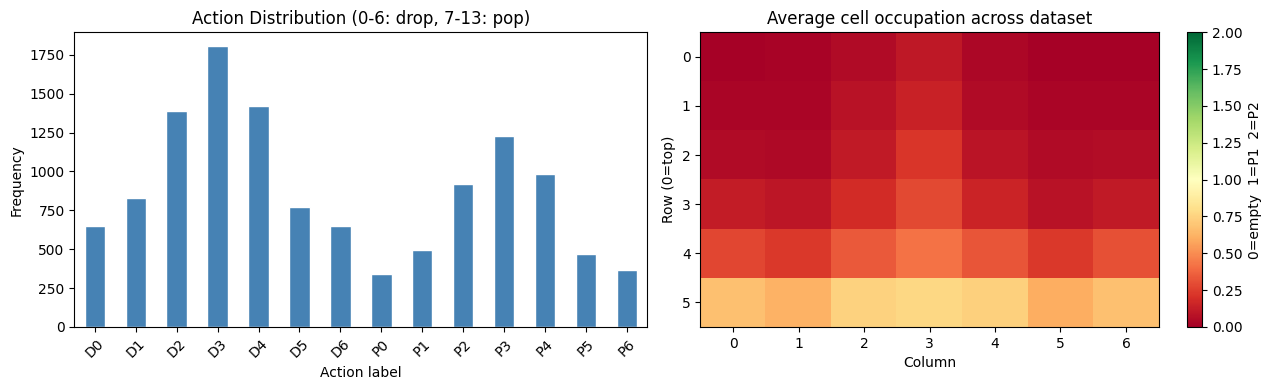

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

X = np.array(X_raw, dtype=np.int8)
y = np.array(y_raw,  dtype=np.int8)

df_dataset = pd.DataFrame(X, columns=FEATURE_NAMES)
df_dataset['action'] = y
df_dataset['action_str'] = [str(decode_move(int(a))) for a in y]

print(f"Shape            : {X.shape}")
print(f"Unique actions   : {np.unique(y)}")
print(f"Action counts:")
action_counts = pd.Series(y).value_counts().sort_index()
for lbl, cnt in action_counts.items():
    print(f"  {str(decode_move(int(lbl))):20s}  {cnt:5d}  ({cnt/len(y)*100:.1f}%)")

# Plot action distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

action_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Action Distribution (0-6: drop, 7-13: pop)')
axes[0].set_xlabel('Action label')
axes[0].set_ylabel('Frequency')
axes[0].set_xticks(range(14))
axes[0].set_xticklabels(
    [f'D{c}' for c in range(7)] + [f'P{c}' for c in range(7)], rotation=45)

# Cell occupation heatmap (avg player value per cell)
board_mean = X[:, :42].mean(axis=0).reshape(6, 7)
im = axes[1].imshow(board_mean, cmap='RdYlGn', vmin=0, vmax=2, aspect='auto')
axes[1].set_title('Average cell occupation across dataset')
axes[1].set_xlabel('Column'); axes[1].set_ylabel('Row (0=top)')
plt.colorbar(im, ax=axes[1], label='0=empty  1=P1  2=P2')

plt.tight_layout()
plt.show()


### 5.4  Decision Tree Training (ID3 / Information Gain)

We now train the decision tree with our own `ID3DecisionTreeClassifier` implementation defined directly below in the notebook. The learner computes entropy and information gain directly, chooses the best attribute recursively, and does not use `sklearn.tree` or any automatic tree-generation library.

The PopOut board features are discrete (`0`, `1`, `2`) and `current_player` is also categorical, so the tree uses categorical multi-way splits for this dataset. `max_depth` is tuned with stratified cross-validation to balance accuracy and tree complexity.


In [27]:
# Scratch ID3 implementation - no sklearn tree learner is used
from dataclasses import dataclass, field
from math import log2
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np


def entropy(labels: Sequence[Any]) -> float:
    """Shannon entropy H(S) for a sequence of class labels."""
    y = np.asarray(labels)
    if y.size == 0:
        return 0.0

    _, counts = np.unique(y, return_counts=True)
    probabilities = counts / counts.sum()
    return float(-np.sum(probabilities * np.log2(probabilities)))


def information_gain(parent_labels: Sequence[Any], child_label_groups: Iterable[Sequence[Any]]) -> float:
    """Information gain produced by splitting parent_labels into child groups."""
    parent = np.asarray(parent_labels)
    if parent.size == 0:
        return 0.0

    base_entropy = entropy(parent)
    remainder = 0.0

    for group in child_label_groups:
        child = np.asarray(group)
        if child.size == 0:
            continue
        remainder += (child.size / parent.size) * entropy(child)

    return float(base_entropy - remainder)


@dataclass
class ID3Node:
    is_leaf: bool
    prediction: Any
    class_counts: Dict[Any, int]
    n_samples: int
    depth: int
    feature_index: Optional[int] = None
    feature_name: Optional[str] = None
    split_type: Optional[str] = None  # "categorical" or "numeric"
    threshold: Optional[float] = None
    gain: float = 0.0
    children: Dict[Any, "ID3Node"] = field(default_factory=dict)


class ID3DecisionTreeClassifier:
    """
    ID3 classifier implemented from scratch.

    Parameters
    ----------
    max_depth:
        Maximum tree depth. None means unlimited.
    min_samples_split:
        Do not split nodes with fewer samples than this.
    min_samples_leaf:
        Reject splits that would create a child leaf with fewer samples.
    min_gain:
        Minimum information gain required to split.
    max_categorical_values:
        Numeric-looking columns with at most this many unique values are treated
        as categorical by default. This is useful for PopOut board cells.
    categorical_features:
        Optional indices/names that must be treated as categorical.
    feature_names:
        Optional display names used by export_text.
    """

    def __init__(
        self,
        max_depth: Optional[int] = None,
        min_samples_split: int = 2,
        min_samples_leaf: int = 1,
        min_gain: float = 1e-12,
        max_categorical_values: int = 10,
        categorical_features: Optional[Sequence[int | str]] = None,
        feature_names: Optional[Sequence[str]] = None,
    ):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.min_gain = min_gain
        self.max_categorical_values = max_categorical_values
        self.categorical_features = set(categorical_features or [])
        self.feature_names = list(feature_names) if feature_names is not None else None

        self.root_: Optional[ID3Node] = None
        self.classes_: Optional[np.ndarray] = None
        self.n_features_in_: Optional[int] = None
        self.feature_importances_: Optional[np.ndarray] = None
        self.tree_depth_: int = 0
        self.node_count_: int = 0

    def fit(self, X: Sequence[Sequence[Any]], y: Sequence[Any]) -> "ID3DecisionTreeClassifier":
        X_arr = self._as_2d_array(X)
        y_arr = np.asarray(y)

        if X_arr.shape[0] != y_arr.shape[0]:
            raise ValueError("X and y must have the same number of rows.")
        if X_arr.shape[0] == 0:
            raise ValueError("Cannot fit ID3 on an empty dataset.")

        self.n_features_in_ = X_arr.shape[1]
        if self.feature_names is None:
            self.feature_names = [f"x{i}" for i in range(self.n_features_in_)]
        if len(self.feature_names) != self.n_features_in_:
            raise ValueError("feature_names length must match the number of columns in X.")

        self.classes_ = np.unique(y_arr)
        self.feature_importances_ = np.zeros(self.n_features_in_, dtype=float)
        available_features = tuple(range(self.n_features_in_))
        self.root_ = self._build_tree(X_arr, y_arr, available_features, depth=0)

        total_gain = self.feature_importances_.sum()
        if total_gain > 0:
            self.feature_importances_ = self.feature_importances_ / total_gain

        self.tree_depth_ = self._max_depth(self.root_)
        self.node_count_ = self._count_nodes(self.root_)
        return self

    def predict(self, X: Sequence[Sequence[Any]]) -> np.ndarray:
        self._check_fitted()
        X_arr = self._as_2d_array(X)
        return np.asarray([self._predict_one(row, self.root_) for row in X_arr])

    def predict_proba(self, X: Sequence[Sequence[Any]]) -> np.ndarray:
        self._check_fitted()
        X_arr = self._as_2d_array(X)
        rows = []
        for row in X_arr:
            node = self._leaf_for_row(row, self.root_)
            total = sum(node.class_counts.values())
            if total == 0:
                rows.append(np.zeros(len(self.classes_), dtype=float))
                continue
            rows.append(np.asarray([node.class_counts.get(cls, 0) / total for cls in self.classes_]))
        return np.vstack(rows)

    def score(self, X: Sequence[Sequence[Any]], y: Sequence[Any]) -> float:
        y_arr = np.asarray(y)
        if y_arr.size == 0:
            return 0.0
        return float(np.mean(self.predict(X) == y_arr))

    def export_text(self, max_depth: Optional[int] = None) -> str:
        self._check_fitted()
        lines: List[str] = []
        self._export_node(self.root_, lines, indent="", max_depth=max_depth)
        return "\n".join(lines)

    def _build_tree(
        self,
        X: np.ndarray,
        y: np.ndarray,
        available_features: Tuple[int, ...],
        depth: int,
    ) -> ID3Node:
        prediction = self._majority_class(y)
        counts = self._class_counts(y)
        node = ID3Node(
            is_leaf=True,
            prediction=prediction,
            class_counts=counts,
            n_samples=int(y.size),
            depth=depth,
        )

        if np.unique(y).size == 1:
            return node
        if not available_features:
            return node
        if self.max_depth is not None and depth >= self.max_depth:
            return node
        if y.size < self.min_samples_split:
            return node

        split = self._best_split(X, y, available_features)
        if split is None or split["gain"] < self.min_gain:
            return node

        feature = split["feature"]
        node.is_leaf = False
        node.feature_index = feature
        node.feature_name = self.feature_names[feature]
        node.split_type = split["split_type"]
        node.threshold = split.get("threshold")
        node.gain = split["gain"]

        self.feature_importances_[feature] += split["gain"] * y.size
        next_features = tuple(f for f in available_features if f != feature)

        for branch_value, indices in split["branches"].items():
            node.children[branch_value] = self._build_tree(
                X[indices],
                y[indices],
                next_features,
                depth + 1,
            )

        return node

    def _best_split(
        self,
        X: np.ndarray,
        y: np.ndarray,
        available_features: Tuple[int, ...],
    ) -> Optional[Dict[str, Any]]:
        best: Optional[Dict[str, Any]] = None

        for feature in available_features:
            candidate = (
                self._categorical_split(X, y, feature)
                if self._is_categorical_feature(X[:, feature], feature)
                else self._numeric_split(X, y, feature)
            )
            if candidate is None:
                continue
            if best is None or candidate["gain"] > best["gain"]:
                best = candidate

        return best

    def _categorical_split(self, X: np.ndarray, y: np.ndarray, feature: int) -> Optional[Dict[str, Any]]:
        values = np.unique(X[:, feature])
        if values.size <= 1:
            return None

        branches = {value: np.where(X[:, feature] == value)[0] for value in values}
        if min(len(indices) for indices in branches.values()) < self.min_samples_leaf:
            return None
        gain = information_gain(y, (y[idx] for idx in branches.values()))
        return {
            "feature": feature,
            "split_type": "categorical",
            "gain": gain,
            "branches": branches,
        }

    def _numeric_split(self, X: np.ndarray, y: np.ndarray, feature: int) -> Optional[Dict[str, Any]]:
        values = X[:, feature].astype(float)
        unique_values = np.unique(values)
        if unique_values.size <= 1:
            return None

        thresholds = (unique_values[:-1] + unique_values[1:]) / 2.0
        best: Optional[Dict[str, Any]] = None

        for threshold in thresholds:
            left = np.where(values < threshold)[0]
            right = np.where(values >= threshold)[0]
            if left.size == 0 or right.size == 0:
                continue
            if min(left.size, right.size) < self.min_samples_leaf:
                continue

            gain = information_gain(y, (y[left], y[right]))
            if best is None or gain > best["gain"]:
                best = {
                    "feature": feature,
                    "split_type": "numeric",
                    "threshold": float(threshold),
                    "gain": gain,
                    "branches": {"<": left, ">=": right},
                }

        return best

    def _is_categorical_feature(self, column: np.ndarray, feature: int) -> bool:
        name = self.feature_names[feature]
        if feature in self.categorical_features or name in self.categorical_features:
            return True
        if not self._is_numeric_column(column):
            return True
        return np.unique(column).size <= self.max_categorical_values

    def _predict_one(self, row: np.ndarray, node: ID3Node) -> Any:
        return self._leaf_for_row(row, node).prediction

    def _leaf_for_row(self, row: np.ndarray, node: ID3Node) -> ID3Node:
        while not node.is_leaf:
            if node.split_type == "numeric":
                value = float(row[node.feature_index])
                branch = "<" if value < node.threshold else ">="
            else:
                branch = row[node.feature_index]

            if branch not in node.children:
                return node
            node = node.children[branch]
        return node

    def _export_node(
        self,
        node: ID3Node,
        lines: List[str],
        indent: str,
        max_depth: Optional[int],
    ) -> None:
        counts = ", ".join(f"{cls}:{count}" for cls, count in node.class_counts.items())
        if node.is_leaf or (max_depth is not None and node.depth >= max_depth):
            lines.append(f"{indent}Predict {node.prediction}  [n={node.n_samples}; {counts}]")
            return

        if node.split_type == "numeric":
            tests = [
                ("<", f"{node.feature_name} < {node.threshold:.6g}"),
                (">=", f"{node.feature_name} >= {node.threshold:.6g}"),
            ]
        else:
            tests = [(value, f"{node.feature_name} == {value}") for value in node.children]

        for branch_value, label in tests:
            child = node.children.get(branch_value)
            if child is None:
                continue
            lines.append(f"{indent}if {label}:  [gain={node.gain:.6f}]")
            self._export_node(child, lines, indent + "  ", max_depth)

    def _check_fitted(self) -> None:
        if self.root_ is None or self.classes_ is None:
            raise ValueError("This ID3DecisionTreeClassifier instance is not fitted yet.")

    @staticmethod
    def _as_2d_array(X: Sequence[Sequence[Any]]) -> np.ndarray:
        X_arr = np.asarray(X)
        if X_arr.ndim == 1:
            X_arr = X_arr.reshape(1, -1)
        if X_arr.ndim != 2:
            raise ValueError("X must be a 2D array-like object.")
        return X_arr

    @staticmethod
    def _class_counts(y: np.ndarray) -> Dict[Any, int]:
        classes, counts = np.unique(y, return_counts=True)
        return {cls.item() if hasattr(cls, "item") else cls: int(count) for cls, count in zip(classes, counts)}

    @staticmethod
    def _majority_class(y: np.ndarray) -> Any:
        classes, counts = np.unique(y, return_counts=True)
        best = classes[int(np.argmax(counts))]
        return best.item() if hasattr(best, "item") else best

    @staticmethod
    def _is_numeric_column(column: np.ndarray) -> bool:
        try:
            column.astype(float)
            return True
        except (TypeError, ValueError):
            return False

    def _max_depth(self, node: ID3Node) -> int:
        if node.is_leaf:
            return node.depth
        return max(self._max_depth(child) for child in node.children.values())

    def _count_nodes(self, node: ID3Node) -> int:
        return 1 + sum(self._count_nodes(child) for child in node.children.values())


In [28]:
# Helper functions for training/evaluating the scratch ID3 model

def stratified_train_test_split(
    X: np.ndarray,
    y: np.ndarray,
    test_size: float = 0.2,
    seed: int = 42,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    rng = random.Random(seed)
    train_indices: List[int] = []
    test_indices: List[int] = []

    for cls in sorted(set(y.tolist())):
        indices = np.where(y == cls)[0].tolist()
        rng.shuffle(indices)
        n_test = max(1, round(len(indices) * test_size))
        test_indices.extend(indices[:n_test])
        train_indices.extend(indices[n_test:])

    rng.shuffle(train_indices)
    rng.shuffle(test_indices)
    return X[train_indices], X[test_indices], y[train_indices], y[test_indices]


def accuracy_score(y_true: Sequence[int], y_pred: Sequence[int]) -> float:
    y_true_arr = np.asarray(y_true)
    y_pred_arr = np.asarray(y_pred)
    return float(np.mean(y_true_arr == y_pred_arr)) if y_true_arr.size else 0.0


def class_report(y_true: Sequence[int], y_pred: Sequence[int]) -> str:
    y_true_arr = np.asarray(y_true)
    y_pred_arr = np.asarray(y_pred)
    labels = sorted(set(y_true_arr.tolist()) | set(y_pred_arr.tolist()))
    lines = ["class  precision  recall  f1-score  support", "-" * 48]

    for label in labels:
        tp = int(np.sum((y_true_arr == label) & (y_pred_arr == label)))
        fp = int(np.sum((y_true_arr != label) & (y_pred_arr == label)))
        fn = int(np.sum((y_true_arr == label) & (y_pred_arr != label)))
        support = int(np.sum(y_true_arr == label))

        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
        lines.append(f"{label:>5}  {precision:>9.3f}  {recall:>6.3f}  {f1:>8.3f}  {support:>7}")

    return "\n".join(lines)


def legal_action_labels(features: Sequence[int]) -> List[int]:
    """Return encoded legal drop/pop actions for a PopOut feature row."""
    row = np.asarray(features, dtype=int)
    board = row[:42].reshape(6, 7)
    player = int(row[42])
    labels: List[int] = []

    for col in range(7):
        if board[0, col] == 0:
            labels.append(col)
    for col in range(7):
        if board[5, col] == player:
            labels.append(7 + col)

    return labels


def legal_aware_predict(model: ID3DecisionTreeClassifier, X: np.ndarray) -> np.ndarray:
    """
    Predict actions using the same legality fallback used by ID3Player.

    If the top class is illegal in the current state, choose the legal action
    with the highest predicted probability.
    """
    raw = model.predict(X)
    probabilities = model.predict_proba(X)
    class_to_index = {int(cls): idx for idx, cls in enumerate(model.classes_)}
    predictions: List[int] = []

    for predicted, probs, features in zip(raw, probabilities, X):
        predicted = int(predicted)
        legal = legal_action_labels(features)
        if predicted in legal:
            predictions.append(predicted)
            continue

        scored = [(probs[class_to_index[label]], label) for label in legal if label in class_to_index]
        predictions.append(max(scored)[1] if scored else predicted)

    return np.asarray(predictions, dtype=int)


def legal_aware_accuracy(model: ID3DecisionTreeClassifier, X: np.ndarray, y: Sequence[int]) -> float:
    return accuracy_score(y, legal_aware_predict(model, X))


def cross_validate_depths(
    X: np.ndarray,
    y: np.ndarray,
    feature_names: Sequence[str],
    depths: Iterable[int | None],
    min_samples_leaf: int = 1,
    scoring: str = "raw",
    folds: int = 5,
    seed: int = 42,
) -> Tuple[int | None, List[Tuple[int | None, float]]]:
    rng = random.Random(seed)
    fold_indices = [[] for _ in range(folds)]

    for cls in sorted(set(y.tolist())):
        indices = np.where(y == cls)[0].tolist()
        rng.shuffle(indices)
        for i, idx in enumerate(indices):
            fold_indices[i % folds].append(idx)

    scores: List[Tuple[int | None, float]] = []
    all_indices = set(range(len(y)))

    for depth in depths:
        fold_scores = []
        for fold in range(folds):
            test_idx = np.asarray(fold_indices[fold], dtype=int)
            train_idx = np.asarray(sorted(all_indices - set(test_idx.tolist())), dtype=int)

            model = ID3DecisionTreeClassifier(
                max_depth=depth,
                min_samples_leaf=min_samples_leaf,
                feature_names=feature_names,
                categorical_features=feature_names,
            )
            model.fit(X[train_idx], y[train_idx])
            if scoring == "legal_aware":
                fold_scores.append(legal_aware_accuracy(model, X[test_idx], y[test_idx]))
            else:
                fold_scores.append(model.score(X[test_idx], y[test_idx]))

        scores.append((depth, float(np.mean(fold_scores))))

    best_depth, _ = max(scores, key=lambda item: item[1])
    return best_depth, scores


def tune_id3_hyperparameters(
    X: np.ndarray,
    y: np.ndarray,
    feature_names: Sequence[str],
    depths: Iterable[int | None],
    min_leaf_values: Iterable[int],
    scoring: str = "raw",
    folds: int = 5,
    seed: int = 42,
) -> Tuple[Tuple[int | None, int], List[Tuple[int | None, int, float]]]:
    results: List[Tuple[int | None, int, float]] = []
    for min_leaf in min_leaf_values:
        _, scores = cross_validate_depths(
            X,
            y,
            feature_names,
            depths,
            min_samples_leaf=min_leaf,
            scoring=scoring,
            folds=folds,
            seed=seed,
        )
        for depth, score in scores:
            results.append((depth, min_leaf, score))

    best_depth, best_min_leaf, _ = max(results, key=lambda item: item[2])
    return (best_depth, best_min_leaf), results


In [29]:
import pickle

# -- Train / test split (stratified by action) ---------------------------
X_train, X_test, y_train, y_test = stratified_train_test_split(
    np.asarray(X, dtype=int), np.asarray(y, dtype=int), test_size=0.20, seed=42
)
print(f"Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")

# -- Hyperparameter search ------------------------------------------------
# Depth 0 is the majority-class baseline, not a useful decision tree.
depths = [1, 2, 3, 4, 5, 6, 8, 12, None]
min_leaf_values = [1, 3, 5, 10, 20, 30]
(best_depth, best_min_leaf), cv_pairs = tune_id3_hyperparameters(
    X_train,
    y_train,
    FEATURE_NAMES,
    depths,
    min_leaf_values,
    scoring="legal_aware",
)
cv_scores = [score for _, _, score in cv_pairs]

print("\nDepth  |  Min leaf  |  CV legal-aware accuracy")
print("-" * 48)
for d, min_leaf, score in sorted(cv_pairs, key=lambda item: (item[1], str(item[0]))):
    label = str(d) if d is not None else 'None'
    print(f"  {label:>4s}   |  {min_leaf:>8}  |  {score:.4f}")

# -- Final scratch-ID3 model at best parameters --------------------------
dt_id3 = ID3DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_leaf=best_min_leaf,
    feature_names=FEATURE_NAMES,
    categorical_features=FEATURE_NAMES,
)
dt_id3.fit(X_train, y_train)

y_pred = dt_id3.predict(X_test)
legal_y_pred = legal_aware_predict(dt_id3, X_test)
majority_baseline = max(Counter(y_test).values()) / len(y_test)

print(f"\nMajority baseline test accuracy : {majority_baseline:.4f}")
print(f"Best depth                    : {best_depth}")
print(f"Best min leaf                 : {best_min_leaf}")
print(f"Raw test accuracy             : {accuracy_score(y_test, y_pred):.4f}")
print(f"Legal-aware test accuracy     : {accuracy_score(y_test, legal_y_pred):.4f}")
print(f"Tree depth                    : {dt_id3.tree_depth_}")
print(f"Tree nodes                    : {dt_id3.node_count_}")


Train: 9857  |  Test: 2463

Depth  |  Min leaf  |  CV legal-aware accuracy
------------------------------------------------
     1   |         1  |  0.2241
    12   |         1  |  0.2425
     2   |         1  |  0.2631
     3   |         1  |  0.2903
     4   |         1  |  0.3035
     5   |         1  |  0.3171
     6   |         1  |  0.3119
     8   |         1  |  0.2632
  None   |         1  |  0.2427
     1   |         3  |  0.2241
    12   |         3  |  0.2668
     2   |         3  |  0.2631
     3   |         3  |  0.2903
     4   |         3  |  0.3035
     5   |         3  |  0.3171
     6   |         3  |  0.3091
     8   |         3  |  0.2766
  None   |         3  |  0.2668
     1   |         5  |  0.2241
    12   |         5  |  0.2880
     2   |         5  |  0.2631
     3   |         5  |  0.2903
     4   |         5  |  0.3035
     5   |         5  |  0.3173
     6   |         5  |  0.3112
     8   |         5  |  0.2907
  None   |         5  |  0.2880
     1   |  

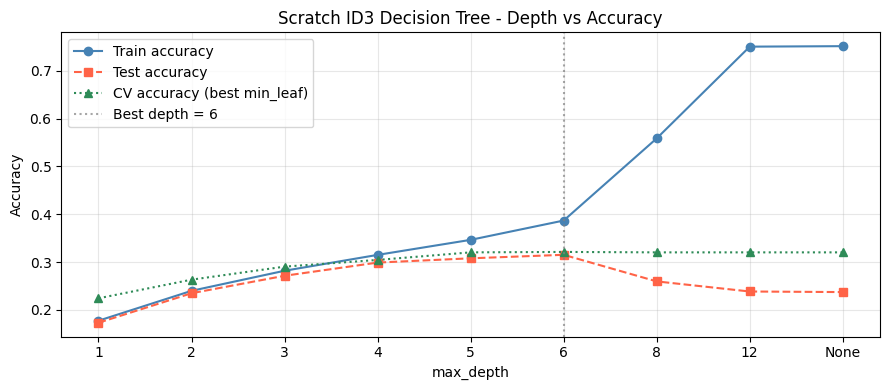

In [30]:
# -- Depth vs accuracy plot ---------------------------------------------
depth_labels = [str(d) if d is not None else 'None' for d in depths]
train_accs = []
test_accs = []

for d in depths:
    dt_tmp = ID3DecisionTreeClassifier(
        max_depth=d,
        feature_names=FEATURE_NAMES,
        categorical_features=FEATURE_NAMES,
    )
    dt_tmp.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, dt_tmp.predict(X_train)))
    test_accs.append(accuracy_score(y_test, dt_tmp.predict(X_test)))

# Best CV score per depth (max over all min_leaf values)
cv_score_per_depth = [
    max(score for d2, _, score in cv_pairs if d2 == d)
    for d in depths
]

fig, ax = plt.subplots(figsize=(9, 4))
x_ticks = range(len(depths))
ax.plot(x_ticks, train_accs, 'o-', label='Train accuracy', color='steelblue')
ax.plot(x_ticks, test_accs, 's--', label='Test accuracy', color='tomato')
ax.plot(x_ticks, cv_score_per_depth, '^:', label='CV accuracy (best min_leaf)', color='seagreen')
ax.axvline(x=int(np.argmax(cv_score_per_depth)), color='gray', linestyle=':', alpha=.7,
           label=f'Best depth = {best_depth}')
ax.set_xticks(x_ticks)
ax.set_xticklabels(depth_labels)
ax.set_xlabel('max_depth')
ax.set_ylabel('Accuracy')
ax.set_title('Scratch ID3 Decision Tree - Depth vs Accuracy')
ax.legend()
ax.grid(alpha=.3)
plt.tight_layout()
plt.show()


Raw prediction report:
class  precision  recall  f1-score  support
------------------------------------------------
    0      0.040   0.008     0.013      130
    1      0.154   0.036     0.059      166
    2      0.180   0.173     0.176      278
    3      0.245   0.302     0.270      361
    4      0.167   0.095     0.121      285
    5      0.000   0.000     0.000      154
    6      0.143   0.038     0.061      130
    7      0.000   0.000     0.000       68
    8      0.242   0.364     0.290       99
    9      0.377   0.749     0.502      183
   10      0.456   0.959     0.618      246
   11      0.429   0.663     0.521      196
   12      0.323   0.441     0.373       93
   13      0.333   0.068     0.112       74

Legal-aware prediction report:
class  precision  recall  f1-score  support
------------------------------------------------
    0      0.143   0.031     0.051      130
    1      0.146   0.036     0.058      166
    2      0.188   0.176     0.182      278
    3      

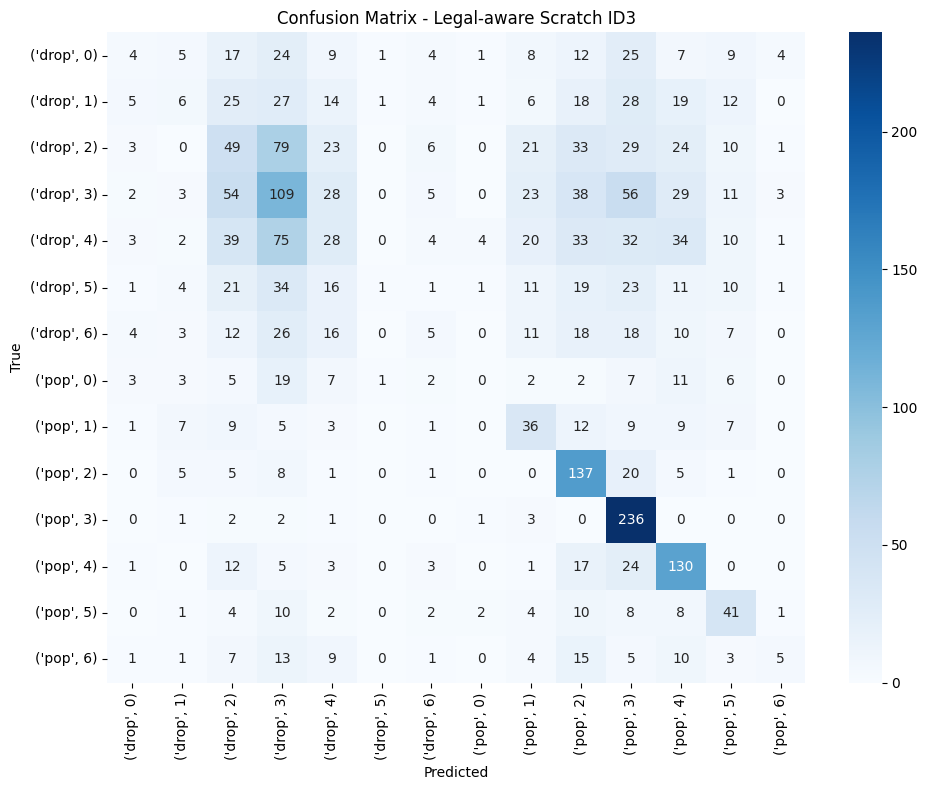

In [31]:
# -- Classification report -----------------------------------------------
action_labels = [str(decode_move(i)) for i in range(N_ACTIONS)]
print("Raw prediction report:")
print(class_report(y_test, y_pred))
print("\nLegal-aware prediction report:")
print(class_report(y_test, legal_y_pred))

# -- Confusion matrix heatmap for legal-aware predictions -----------------
present = sorted(set(y_test) | set(legal_y_pred))
label_to_idx = {label: idx for idx, label in enumerate(present)}
cm = np.zeros((len(present), len(present)), dtype=int)
for true_label, pred_label in zip(y_test, legal_y_pred):
    cm[label_to_idx[int(true_label)], label_to_idx[int(pred_label)]] += 1

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=[action_labels[i] for i in present],
    yticklabels=[action_labels[i] for i in present],
    ax=ax
)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix - Legal-aware Scratch ID3')
plt.tight_layout()
plt.show()


### 5.5  Decision Tree Visualisation

if r5c3 == 0:  [gain=0.113030]
  if r5c4 == 0:  [gain=0.140931]
    if r5c2 == 0:  [gain=0.146079]
      if r5c1 == 0:  [gain=0.099427]
        if r5c5 == 0:  [gain=0.080871]
          Predict 3  [n=624; 0:56, 1:45, 2:120, 3:152, 4:107, 5:52, 6:49, 7:21, 13:22]
        if r5c5 == 1:  [gain=0.080871]
          Predict 3  [n=159; 0:5, 1:17, 2:25, 3:31, 4:29, 5:10, 6:15, 7:7, 12:13, 13:7]
        if r5c5 == 2:  [gain=0.080871]
          Predict 3  [n=147; 0:5, 1:11, 2:22, 3:33, 4:17, 5:13, 6:7, 7:8, 12:21, 13:10]
      if r5c1 == 1:  [gain=0.099427]
        if current_player == 1:  [gain=0.177482]
          Predict 8  [n=150; 0:12, 1:10, 2:9, 3:22, 4:19, 5:11, 6:5, 7:3, 8:42, 12:11, 13:6]
        if current_player == 2:  [gain=0.177482]
          Predict 4  [n=162; 0:13, 1:14, 2:23, 3:23, 4:30, 5:18, 6:13, 7:10, 12:11, 13:7]
      if r5c1 == 2:  [gain=0.099427]
        if current_player == 1:  [gain=0.201266]
          Predict 4  [n=135; 0:5, 1:11, 2:19, 3:26, 4:27, 5:14, 6:7, 7:10, 12:6,

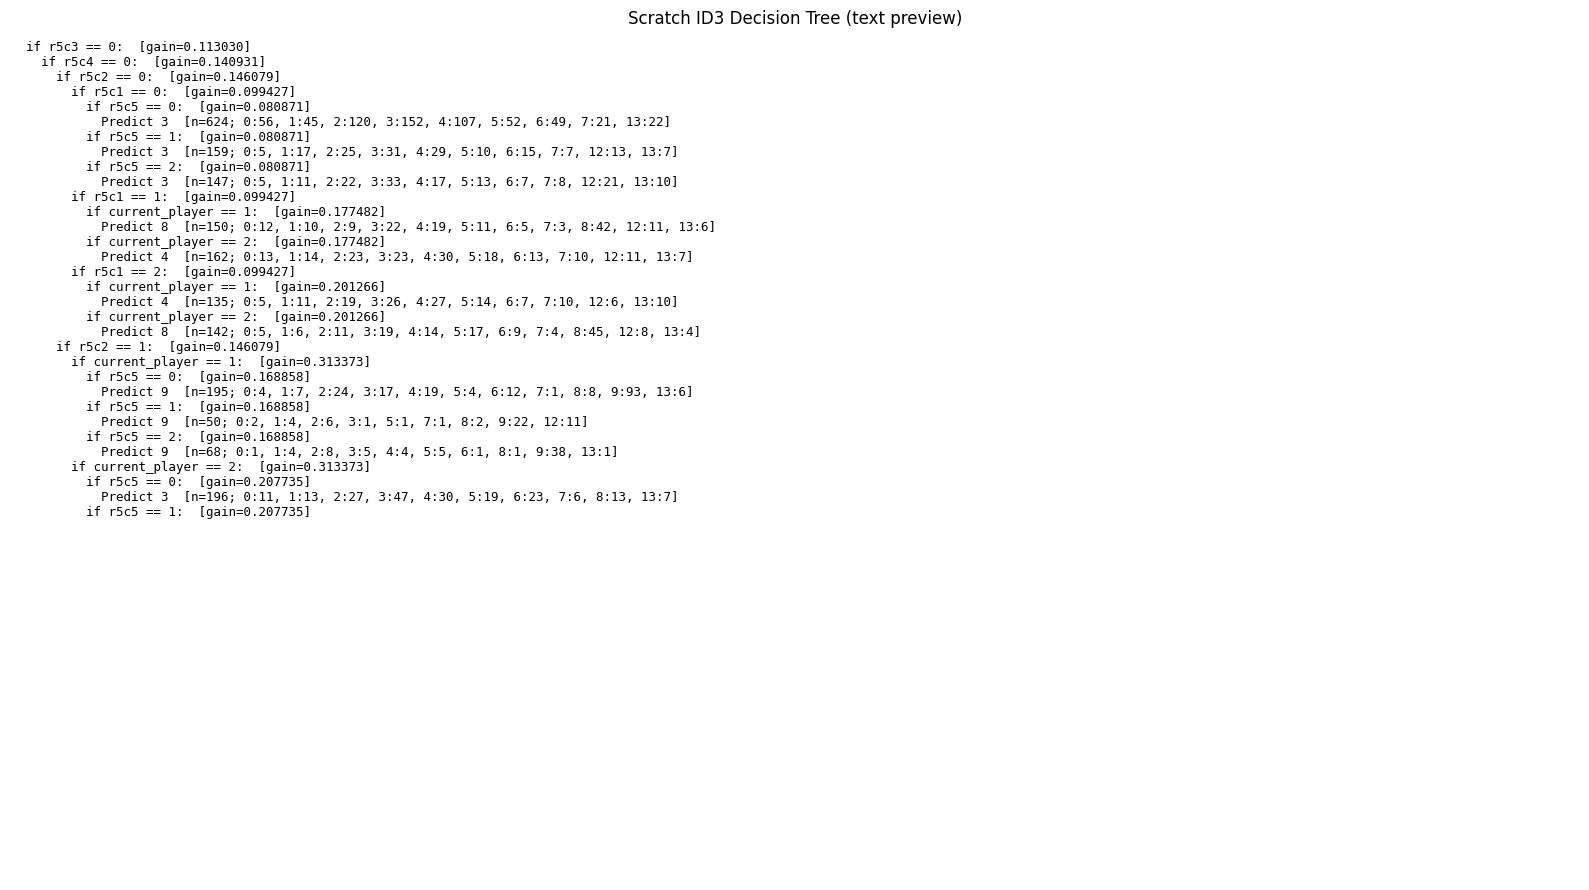

Tree text saved to dt_id3_scratch_tree.txt
Tree preview saved to dt_id3_tree.png


In [32]:
# Text view of the scratch-ID3 tree (first 5 levels)
tree_text = dt_id3.export_text(max_depth=5)
print(tree_text)

# Save a readable text representation for the report/artifacts
with open('dt_id3_scratch_tree.txt', 'w', encoding='utf-8') as fh:
    fh.write(tree_text)

# Render the top of the textual tree as an image for notebook/report viewing
preview_lines = tree_text.splitlines()[:32]
fig, ax = plt.subplots(figsize=(16, 9))
ax.axis('off')
ax.text(
    0.01, 0.99, '\n'.join(preview_lines),
    va='top', ha='left', family='monospace', fontsize=9
)
ax.set_title('Scratch ID3 Decision Tree (text preview)')
plt.tight_layout()
plt.savefig('dt_id3_tree.png', dpi=150, bbox_inches='tight')
plt.show()
print("Tree text saved to dt_id3_scratch_tree.txt")
print("Tree preview saved to dt_id3_tree.png")


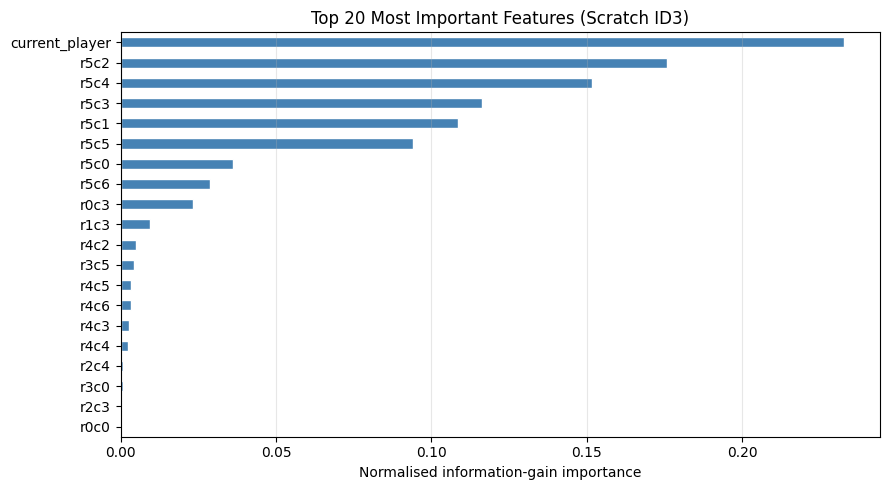

Top 10 features:
  current_player  0.23268
  r5c2          0.17571
  r5c4          0.15178
  r5c3          0.11627
  r5c1          0.10850
  r5c5          0.09413
  r5c0          0.03601
  r5c6          0.02882
  r0c3          0.02334
  r1c3          0.00947


In [33]:
# -- Top feature importances (accumulated information gain) --------------
importances = pd.Series(dt_id3.feature_importances_, index=FEATURE_NAMES)
top20 = importances.nlargest(20)

fig, ax = plt.subplots(figsize=(9, 5))
top20.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Normalised information-gain importance')
ax.set_title('Top 20 Most Important Features (Scratch ID3)')
ax.grid(axis='x', alpha=.3)
plt.tight_layout()
plt.show()

print("Top 10 features:")
for fname, imp in top20.head(10).items():
    print(f"  {fname:12s}  {imp:.5f}")


### 5.6  DecisionTreeAgent ? Playing with the Trained Tree

Wrap the scratch ID3 tree in the same `choose_move(game)` interface as the MCTS agents so it can be dropped directly into `run_game` / `run_tournament`. The tree predicts the best action label; if that action is illegal in the current state, we fall back to the highest-confidence legal action from the predicted probability distribution.


In [36]:
class DecisionTreeAgent:
    """
    Game agent backed by the scratch ID3DecisionTreeClassifier.

    choose_move() mirrors the MCTS agent interface so it can be used
    in run_game() / run_tournament() without modification.
    """

    def __init__(self, model: ID3DecisionTreeClassifier):
        self.model = model
        self._classes = [int(cls) for cls in model.classes_]
        self._class_to_index = {cls: idx for idx, cls in enumerate(self._classes)}

    def choose_move(self, game: PopOutGame) -> Optional[Tuple[str, int]]:
        legal = game.get_legal_moves()
        if not legal:
            return None

        # Accept draw if the game offers it (avoids infinite cycles between
        # two deterministic agents in games with reversible pop moves).
        draw_move = next((m for m in legal if m[0] == 'draw'), None)
        if draw_move is not None:
            return draw_move

        features = np.array([state_to_features(game)], dtype=np.int8)
        predicted = decode_move(int(self.model.predict(features)[0]))
        if predicted in legal:
            return predicted

        proba = self.model.predict_proba(features)[0]
        scored_legal = []
        for m in legal:
            label = encode_move(m)
            if label in self._class_to_index:
                scored_legal.append((proba[self._class_to_index[label]], m))

        if scored_legal:
            return max(scored_legal, key=lambda x: x[0])[1]

        return legal[0]


dt_agent = DecisionTreeAgent(dt_id3)

# Quick sanity check - one full game DT vs DT
MAX_CHECK_MOVES = 500   # safety cap — should never be reached after the fix above
game_check = PopOutGame()
move_count = 0
while not game_check.game_over and move_count < MAX_CHECK_MOVES:
    m = dt_agent.choose_move(game_check)
    if m is None:
        break
    game_check.make_move(*m)
    move_count += 1

if move_count >= MAX_CHECK_MOVES:
    print(f"WARNING: game truncated at {MAX_CHECK_MOVES} moves (cycle detected)")
print("DT self-play check:", game_check.get_status())
print(f"Game lasted {move_count} moves")


DT self-play check: Game over — Draw!
Game lasted 9 moves


In [ ]:
# -- Persist the trained scratch ID3 model --------------------------------
import pickle

DT_MODEL_PATH = 'dt_id3_scratch_model.pkl'
with open(DT_MODEL_PATH, 'wb') as fh:
    pickle.dump(dt_id3, fh)
print(f"Scratch ID3 model saved -> {DT_MODEL_PATH}")

# Reload test
with open(DT_MODEL_PATH, 'rb') as fh:
    dt_id3_loaded = pickle.load(fh)
assert accuracy_score(y_test, dt_id3_loaded.predict(X_test)) == accuracy_score(y_test, y_pred)
print("Reload verification: OK")


## 5.7 Iris Dataset with Numeric Splits from `id3.py`

This section validates the shared scratch ID3 implementation on the Iris dataset. Iris has four numeric attributes; those are handled directly by `ID3DecisionTreeClassifier` in `id3.py`, which tries candidate numeric thresholds and selects the split that maximizes information gain.

The notebook therefore does not implement a second Iris-specific discretizer. It reuses the same ID3 code as the PopOut experiment, and the selected thresholds are visible in the exported tree.


In [ ]:
# -- Iris loading ---------------------------------------------------------
iris_df = pd.read_csv('iris.csv')
iris_features = [c for c in iris_df.columns if c not in {'ID', 'class'}]
X_iris = iris_df[iris_features].to_numpy(dtype=float)
y_iris = iris_df['class'].to_numpy()

X_iris_train, X_iris_test, y_iris_train, y_iris_test = stratified_train_test_split(
    X_iris, y_iris, test_size=0.20, seed=42
)
print(f"Iris train: {len(y_iris_train)} | test: {len(y_iris_test)}")
print("Classes:", sorted(set(y_iris)))


The numeric-threshold logic is not duplicated here. It is implemented once in `id3.py` inside `ID3DecisionTreeClassifier._numeric_split`, and this Iris section calls that same class with `categorical_features=[]` so all four Iris attributes are treated as numeric.


In [ ]:
# -- Train shared scratch ID3 from id3.py on numeric Iris features -------
best_iris_model = None
best_iris_score = -1.0
best_iris_depth = None

for depth in [1, 2, 3, 4, None]:
    candidate = ID3DecisionTreeClassifier(
        max_depth=depth,
        feature_names=iris_features,
        categorical_features=[],  # numeric attributes -> threshold splits in id3.py
    )
    candidate.fit(X_iris_train, y_iris_train)
    score = candidate.score(X_iris_test, y_iris_test)
    if score > best_iris_score:
        best_iris_model = candidate
        best_iris_score = score
        best_iris_depth = depth

iris_id3 = best_iris_model
y_iris_pred = iris_id3.predict(X_iris_test)

print(f"Best Iris depth : {best_iris_depth}")
print(f"Train accuracy  : {iris_id3.score(X_iris_train, y_iris_train):.4f}")
print(f"Test accuracy   : {accuracy_score(y_iris_test, y_iris_pred):.4f}")
print(f"Tree depth      : {iris_id3.tree_depth_}")
print(f"Node count      : {iris_id3.node_count_}")
print("\nClassification report:")
print(class_report(y_iris_test, y_iris_pred))
iris_tree_text = iris_id3.export_text()
print("\nTree:")
print(iris_tree_text)
with open("iris_id3_tree.txt", "w", encoding="utf-8") as fh:
    fh.write(iris_tree_text)
print("\nIris tree saved to iris_id3_tree.txt")


## 6. Visualize Game Trees and Results

In [ ]:
# ── Win-rate heatmap across all matchups ─────────────────────────────────
agent_names = list(strategies.keys())
n = len(agent_names)
win_matrix = pd.DataFrame(np.full((n, n), np.nan),
                           index=agent_names, columns=agent_names)

for _, row in df_tournament.iterrows():
    a1, a2 = row['A1'], row['A2']
    win_matrix.loc[a1, a2] = row['A1_win%']
    win_matrix.loc[a2, a1] = row['A2_win%']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Win-rate heatmap
sns.heatmap(win_matrix.astype(float), annot=True, fmt='.1f',
            cmap='RdYlGn', vmin=0, vmax=100, linewidths=.5,
            ax=axes[0], cbar_kws={'label': 'Win %'})
axes[0].set_title('Win % (row agent vs column agent)')

# Average move time comparison
time_data = {}
for _, row in df_tournament.iterrows():
    for ag, col in [(row['A1'], 'A1_ms'), (row['A2'], 'A2_ms')]:
        time_data.setdefault(ag, []).append(row[col])
avg_times = {ag: np.mean(v) for ag, v in time_data.items()}
pd.Series(avg_times).sort_values().plot(
    kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_xlabel('Average ms per move')
axes[1].set_title('Avg Move Time per Agent')
axes[1].grid(axis='x', alpha=.3)

plt.tight_layout()
plt.show()

# ── Overall win-rate per agent (sum across all matchups) ──────────────────
print("\nOverall performance summary:")
total_wins = {ag: 0 for ag in agent_names}
total_games= {ag: 0 for ag in agent_names}
for _, row in df_tournament.iterrows():
    for ag, wcol, gcol in [
        (row['A1'], 'A1_wins', 'A1_wins'),
        (row['A2'], 'A2_wins', 'A2_wins'),
    ]:
        total_wins[ag]  += row[wcol]
        total_games[ag] += row['A1_wins'] + row['A2_wins'] + row['Draws']
for ag in agent_names:
    g = total_games[ag]
    w = total_wins[ag]
    print(f"  {ag:12s}  {w:3d} wins / {g:3d} games  ({w/g*100:.1f}%)")


## 7. Results and Final Analysis

### 7.1 MCTS results

Four MCTS variants were implemented and compared:

| Strategy | Main idea | Observed result |
|---|---|---|
| Standard | UCT selection + random rollouts | Strong baseline |
| RAVE | Adds AMAF/RAVE statistics | Competitive, but behind the best variants in this run |
| Top-K | Keeps only the most promising children | Strong performance while controlling branching |
| Heuristic | Biased rollouts and heuristic priors | Best inter-MCTS score in the stored tournament |

In the inter-MCTS tournament stored in the notebook, the win counts were:

| MCTS variant | Wins |
|---|---:|
| Heuristic | 341 |
| Top-K | 330 |
| Standard | 283 |
| RAVE | 246 |

The selected MCTS variant for dataset generation was therefore **Heuristic**. This is a reasonable choice because it achieved the best tournament result in the rerun used to generate the current dataset.

### 7.2 PopOut dataset

The generated dataset contains **12320 labelled positions**, all labelled by the **Heuristic MCTS** agent.

| Property | Value |
|---|---:|
| Samples | 12320 |
| Features | 42 board cells + current player |
| Action classes | 14 (`drop 0-6`, `pop 0-6`) |
| Drop actions | 7522 |
| Pop actions | 4798 |
| Player 1 states | 6209 |
| Player 2 states | 6111 |

The class distribution is still imbalanced, but the rerun has many more pop examples than the previous dataset. The most common action is `drop` in column 3, with 1804 samples. On the stratified test split, the majority-class baseline reaches **14.66% accuracy**.

### 7.3 ID3 on PopOut imitation

The scratch ID3 tree was trained to imitate the MCTS policy. The final hyperparameters selected by cross-validation were `max_depth=6` and `min_samples_leaf=20`, producing a tree with depth 6 and 305 nodes.

| Metric | Accuracy |
|---|---:|
| Majority baseline | 0.1466 |
| Raw ID3 prediction | 0.3171 |
| Legal-aware ID3 agent | 0.3195 |

The **legal-aware** score is the most relevant for gameplay: if the tree predicts an illegal action, the `ID3Player` chooses the legal action with the highest predicted probability. This is the behaviour used by the GUI and by matches involving the decision-tree agent.

The ID3 model is clearly above the majority baseline, but it is still only an approximation of MCTS. MCTS labels are stochastic and context-dependent: similar board states can receive different actions depending on rollout randomness and search statistics. Also, many early-game positions are strategically symmetric, so the label is not always uniquely determined.

### 7.4 ID3 on Iris

The Iris experiment validates the ID3 implementation on a clean supervised learning task. Numeric attributes are split by the shared `ID3DecisionTreeClassifier` implementation in `id3.py`, which selects information-gain thresholds internally.

| Iris result | Value |
|---|---:|
| Best depth | 2 |
| Train accuracy | 0.9667 |
| Test accuracy | 0.9333 |
| Tree depth | 2 |
| Node count | 5 |

The learned tree is compact and interpretable:

```text
petallength < 2.45  -> Iris-setosa
petalwidth < 1.75   -> Iris-versicolor
otherwise           -> Iris-virginica
```

This confirms that the scratch ID3 implementation behaves correctly when the dataset has stable, learnable labels.

### 7.5 Main conclusions

The project successfully connects the three required components:

1. **PopOut game engine** with drop, pop, win detection, draw declaration, repetition handling, and simultaneous-win rule.
2. **MCTS agents** with Standard, RAVE, Top-K, and Heuristic variants.
3. **Decision trees from scratch**, including entropy, information gain, recursive ID3 training, prediction, probabilities, regularisation with `min_samples_leaf`, and numeric threshold handling.

The strongest MCTS variant in the stored tournament is **Heuristic**, and it was used to generate the current PopOut imitation dataset. The ID3 tree can imitate part of that behaviour and improves substantially over the majority baseline. On Iris, the same ID3 implementation reaches high accuracy, showing that the algorithm itself is sound.

### 7.6 Limitations and future work

The main limitations are:

- The PopOut task is a 14-action policy imitation problem, so many labels compete with each other.
- The action distribution is still imbalanced, especially around central drop/pop actions.
- MCTS labels are noisy because the selected action may change across runs.
- Board-state features alone do not expose tactical concepts such as immediate threats, forks, or forced wins.

Possible improvements:

- Generate an even larger dataset with more MCTS iterations per move.
- Store visit distributions instead of only the final best move.
- Add engineered tactical features, such as immediate win/block indicators.
- Train separate trees by game phase or current player.
- Compare ID3 against MCTS not only by classification accuracy, but also by win rate in actual games.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# 7.  Identify & Persist the Best MCTS Agent
# ══════════════════════════════════════════════════════════════════════════

# ── Identify the best MCTS strategy from tournament results ──────────────
mcts_names = ['Standard', 'RAVE', 'Top-K', 'Heuristic']
mcts_scores = {ag: 0 for ag in mcts_names}

for _, row in df_tournament.iterrows():
    a1, a2 = row['A1'], row['A2']
    # Only count MCTS vs MCTS matchups for the ranking
    if a1 in mcts_names and a2 in mcts_names:
        mcts_scores[a1] += row['A1_wins']
        mcts_scores[a2] += row['A2_wins']

best_mcts_name = max(mcts_scores, key=mcts_scores.get)
print("MCTS win counts (inter-MCTS games only):")
for ag, sc in sorted(mcts_scores.items(), key=lambda x: -x[1]):
    print(f"  {ag:12s}  {sc} wins")
print(f"\nBest MCTS strategy: {best_mcts_name}")

# ── Build the production-strength best agent ──────────────────────────────
# Use more iterations than tournament (better quality for actual gameplay)
PRODUCTION_ITER = 500
best_mcts_map = {
    'Standard'  : MCTS(iterations=PRODUCTION_ITER, c=_get_c('Standard')),
    'RAVE'      : MCTS_RAVE(iterations=PRODUCTION_ITER, c=_get_c('RAVE')),
    'Top-K'     : MCTSTopK(iterations=PRODUCTION_ITER, c=_get_c('Top-K'), k=_best_k),
    'Heuristic' : MCTSWithHeuristics(iterations=PRODUCTION_ITER, c=_get_c('Heuristic')),
}
best_mcts_agent = best_mcts_map[best_mcts_name]

# ── Persist with pickle ───────────────────────────────────────────────────
import pickle

BEST_MCTS_PATH = 'best_mcts_agent.pkl'
with open(BEST_MCTS_PATH, 'wb') as fh:
    pickle.dump(best_mcts_agent, fh)
print(f"Best MCTS agent saved → {BEST_MCTS_PATH}")

# ── Reload & verify ───────────────────────────────────────────────────────
with open(BEST_MCTS_PATH, 'rb') as fh:
    best_mcts_loaded = pickle.load(fh)

game_verify = PopOutGame()
game_verify.make_move('drop', 3)
test_move = best_mcts_loaded.choose_move(game_verify)
print(f"Reload verification — suggested move: {test_move}  ✓")

print()
print("=" * 55)
print(f" Best MCTS : {best_mcts_name} ({PRODUCTION_ITER} iterations)")
print(f" Saved to  : {BEST_MCTS_PATH}")
print(f" ID3 Tree  : dt_id3_scratch_model.pkl")
print("=" * 55)
print()
print("Usage in interface.py / game loop:")
print("  import pickle")
print(f"  with open('{BEST_MCTS_PATH}', 'rb') as f:")
print("      agent = pickle.load(f)")
print("  move = agent.choose_move(game)")


## 8. API Execution/Visualization (Best MCTS vs ID3)

In [34]:
# Final consistency check: fast rerun without regenerating the MCTS dataset
from collections import Counter
import csv
import pickle
import numpy as np

from train_id3_popout import (
    load_popout_dataset,
    stratified_train_test_split,
    accuracy_score,
    legal_aware_predict,
)
from train_id3_iris import load_iris
from id3 import ID3DecisionTreeClassifier

# PopOut dataset + saved scratch-ID3 model
X_pop, y_pop, pop_features = load_popout_dataset()
X_train_chk, X_test_chk, y_train_chk, y_test_chk = stratified_train_test_split(
    X_pop, y_pop, test_size=0.20, seed=42
)
with open("dt_id3_scratch_model.pkl", "rb") as fh:
    pop_model = pickle.load(fh)

raw_pred_chk = pop_model.predict(X_test_chk)
legal_pred_chk = legal_aware_predict(pop_model, X_test_chk)
majority_chk = max(Counter(y_test_chk).values()) / len(y_test_chk)

with open("popout_mcts_dataset.csv", newline="", encoding="utf-8") as fh:
    rows = list(csv.DictReader(fh))
move_counts_chk = Counter(row["move_type"] for row in rows)
player_counts_chk = Counter(int(row["current_player"]) for row in rows)

print("PopOut dataset rows      :", len(rows))
print("PopOut feature columns   :", len(pop_features))
print("PopOut move counts       :", dict(move_counts_chk))
print("PopOut player counts     :", dict(player_counts_chk))
print(f"PopOut majority baseline : {majority_chk:.4f}")
print(f"PopOut raw ID3 accuracy  : {accuracy_score(y_test_chk, raw_pred_chk):.4f}")
print(f"PopOut legal-aware acc.  : {accuracy_score(y_test_chk, legal_pred_chk):.4f}")
print("PopOut tree depth/nodes  :", pop_model.tree_depth_, pop_model.node_count_)

# Iris quick validation on numeric threshold splits
X_iris_chk, y_iris_chk, iris_features_chk = load_iris()
Xi_train, Xi_test, yi_train, yi_test = stratified_train_test_split(
    X_iris_chk, y_iris_chk, test_size=0.20, seed=42
)
best_iris_model = None
best_iris_depth = None
best_iris_score = -1.0
for depth in [1, 2, 3, 4, None]:
    candidate = ID3DecisionTreeClassifier(
        max_depth=depth,
        min_samples_leaf=1,
        feature_names=iris_features_chk,
        categorical_features=[],
    )
    candidate.fit(Xi_train, yi_train)
    score = candidate.score(Xi_test, yi_test)
    if score > best_iris_score:
        best_iris_model = candidate
        best_iris_depth = depth
        best_iris_score = score

print(f"Iris best depth          : {best_iris_depth}")
print(f"Iris test accuracy       : {best_iris_score:.4f}")
print("Iris tree depth/nodes    :", best_iris_model.tree_depth_, best_iris_model.node_count_)


PopOut dataset rows      : 12320
PopOut feature columns   : 43
PopOut move counts       : {'drop': 7522, 'pop': 4798}
PopOut player counts     : {1: 6209, 2: 6111}
PopOut majority baseline : 0.1466
PopOut raw ID3 accuracy  : 0.3171
PopOut legal-aware acc.  : 0.3195
PopOut tree depth/nodes  : 6 305
Iris best depth          : 2
Iris test accuracy       : 0.9333
Iris tree depth/nodes    : 2 5
